In [1]:
from functions import *
import seaborn as sns
from tqdm import tqdm
from natsort import natsorted
import glob
import os
import matplotlib.ticker as ptick 
from scipy.spatial.distance import euclidean
from rdp import rdp
from pykalman import  KalmanFilter
from scipy.interpolate import UnivariateSpline
from sklearn.ensemble import IsolationForest

import matplotlib
# フォントの設定を Arial に変更
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'

In [93]:
! pip install rdp

  Preparing metadata (setup.py) ... done
  Created wheel for rdp: filename=rdp-0.8-py3-none-any.whl size=4586 sha256=340bdba72589f04bf5a10a7d650b9046cd9895aeb329b0550cd049668683df61
  Stored in directory: /root/.cache/pip/wheels/5d/12/ec/0fc50553af000b9c3d2c74b9f77a01ae4bfe856e9917ac239c
Successfully built rdp


In [5]:
df_bi = pd.read_csv('./csvs/errata_csv/nagoya_D1_L10bi.csv')
df_org = pd.read_csv('./csvs/nagoya_D1_L10.csv')

# State Transition

## Estimate State from Trajectory

### 関数

In [6]:
def create_kalman_filter(x, y):
    """
    カルマンフィルタを初期化します。
    """
    kf = KalmanFilter(initial_state_mean=[x, y, 0, 0],
                      transition_matrices=[[1, 0, 1, 0],
                                           [0, 1, 0, 1],
                                           [0, 0, 1, 0],
                                           [0, 0, 0, 1]],
                      observation_matrices=[[1, 0, 0, 0],
                                            [0, 1, 0, 0]],
                      transition_covariance=0.01 * np.eye(4),
                      observation_covariance=10.0 * np.eye(2),
                      initial_state_covariance=100.0 * np.eye(4))
    return kf

def calculate_angle_between_vectors(T, m, H):
    """
    Calculates the angle θ between the vectors Tm_g and m_gH using vector math.

    Parameters:
    T (np.array): Coordinates of the Tail (T) [x, y].
    m (np.array): Coordinates of the Mid (m) [x, y].
    H (np.array): Coordinates of the Head (H) [x, y].

    Returns:
    float: Angle θ in degrees.
    """
    # Calculate vectors Tm_g and m_gH
    T_mg = m - T  # Vector from Tail to Mid: Tm_g = m - T
    mg_H = H - m  # Vector from Mid to Head: m_gH = H - m

    # Calculate the dot product of the vectors
    dot_product = np.dot(T_mg, mg_H)

    # Calculate magnitudes (norms) of the vectors
    magnitude_T_mg = np.linalg.norm(T_mg)
    magnitude_mg_H = np.linalg.norm(mg_H)

    # Check for zero magnitude to avoid division by zero
    if magnitude_T_mg == 0 or magnitude_mg_H == 0:
        return np.nan

    # Calculate the cosine of the angle using the dot product formula
    cos_theta = dot_product / (magnitude_T_mg * magnitude_mg_H)

    # Clip cos_theta to avoid potential numerical issues outside [-1, 1]
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    # Calculate the angle in radians and then convert to degrees
    theta = np.arccos(cos_theta)  # Radians
    theta_degrees = np.degrees(theta)  # Convert to degrees

    return theta_degrees



def smooth_trajectory_with_flip_correction(data):
    """
    ラルバのトラッキングデータに対してカルマンフィルタとスプライン補間を適用し、
    Head, Middle, Tail の座標を平滑化し、進行方向に基づいて Head と Tail を修正します。
    最後に Smoothed_Angle を計算します。

    Parameters:
        data (pd.DataFrame): トラッキングデータ。必要な列:
            ['ID', 'Frame', 'Middle_X', 'Middle_Y', 'Head_X', 'Head_Y', 'Tail_X', 'Tail_Y']

    Returns:
        pd.DataFrame: 平滑化されたデータ、修正後の Head/Tail、および 'Smoothed_Angle' を含むデータフレーム。
    """
    PIXEL_TO_CM = 6 ** 10e-3
    
    data = data.copy()
    ids = data['ID'].unique()
    smoothed_data = []

    for id_value in tqdm(ids, desc="Smoothing Trajectories"):
        id_data = data[data['ID'] == id_value].sort_values(by='Frame')
        frames = id_data['Frame'].values

        # 対象の列
        columns_to_smooth = ['Middle_X', 'Middle_Y', 'Head_X', 'Head_Y', 'Tail_X', 'Tail_Y']

        for col in columns_to_smooth:
            # 欠損値を線形補間で埋める
            id_data[col] = id_data[col].interpolate(method='linear', limit_direction='both')

        # 各ペア（X, Y）ごとに平滑化を適用
        smoothed_results = {}
        for pair in [('Middle_X', 'Middle_Y'), ('Head_X', 'Head_Y'), ('Tail_X', 'Tail_Y')]:
            x_col, y_col = pair
            observations = id_data[[x_col, y_col]].values

            # 観測データの形状を確認
            if observations.ndim != 2 or observations.shape[1] != 2:
                print(f"ID {id_value} の観測データ {pair} の形状が不正です。スキップします。")
                continue

            kf = create_kalman_filter(observations[0, 0], observations[0, 1])
            state_means, _ = kf.smooth(observations)

            # データポイント数を確認
            m = len(frames)
            # スプラインの次数を設定（デフォルトは3）
            k = 3
            if m <= k:
                # データポイント数が少ない場合は次数を調整
                k = m - 1 if m > 1 else 0  # k は0以上
                if k >= 1:
                    # スプライン補間を次数 k で実行
                    smoothed_x = UnivariateSpline(frames, state_means[:, 0], k=k, s=0)(frames)
                    smoothed_y = UnivariateSpline(frames, state_means[:, 1], k=k, s=0)(frames)
                else:
                    # データポイントが1つまたは0の場合、そのまま使用
                    smoothed_x = state_means[:, 0]
                    smoothed_y = state_means[:, 1]
            else:
                # データポイント数が十分な場合は通常通りスプライン補間
                smoothed_x = UnivariateSpline(frames, state_means[:, 0], s=2)(frames)
                smoothed_y = UnivariateSpline(frames, state_means[:, 1], s=2)(frames)

            # 平滑化結果を格納
            smoothed_results[x_col] = smoothed_x
            smoothed_results[y_col] = smoothed_y

        # 平滑化結果を id_data に追加
        for col in smoothed_results:
            id_data[f'Smoothed_{col}'] = smoothed_results[col]

        # 速度計算のためのシフト列を追加
        id_data['Prev_Smoothed_Middle_X'] = id_data['Smoothed_Middle_X'].shift(1)
        id_data['Prev_Smoothed_Middle_Y'] = id_data['Smoothed_Middle_Y'].shift(1)

        # 速度方向に基づいて Head と Tail を修正
        def correct_flip(row):
            # 平滑化された座標を取得
            head = np.array([row['Smoothed_Head_X'], row['Smoothed_Head_Y']])
            tail = np.array([row['Smoothed_Tail_X'], row['Smoothed_Tail_Y']])
            middle = np.array([row['Smoothed_Middle_X'], row['Smoothed_Middle_Y']])
            prev_middle = np.array([row['Prev_Smoothed_Middle_X'], row['Prev_Smoothed_Middle_Y']])
            
            velocity = middle - prev_middle
            velocity_dir = velocity / (np.linalg.norm(velocity) + 1e-10)  # 小さい値を足してゼロ除算を防止
            head_dir = (head - middle) / (np.linalg.norm(head - middle) + 1e-10)
            head_dir = (head - middle) / np.linalg.norm(head - middle)

            # ベクトルの内積で方向を確認
            if np.dot(velocity_dir, head_dir) < 0:  # 方向が逆の場合
                return pd.Series({
                    'Smoothed_Head_X': row['Smoothed_Tail_X'],
                    'Smoothed_Head_Y': row['Smoothed_Tail_Y'],
                    'Smoothed_Tail_X': row['Smoothed_Head_X'],
                    'Smoothed_Tail_Y': row['Smoothed_Head_Y'],
                })
            else:
                return pd.Series({
                    'Smoothed_Head_X': row['Smoothed_Head_X'],
                    'Smoothed_Head_Y': row['Smoothed_Head_Y'],
                    'Smoothed_Tail_X': row['Smoothed_Tail_X'],
                    'Smoothed_Tail_Y': row['Smoothed_Tail_Y'],
                })

        # Flip の修正結果を id_data に反映
        flip_corrected = id_data.apply(correct_flip, axis=1)
        id_data.update(flip_corrected)

        # Smoothed_Angle を計算
        def compute_angle(row):
            T = np.array([row['Smoothed_Tail_X'], row['Smoothed_Tail_Y']])
            m = np.array([row['Smoothed_Middle_X'], row['Smoothed_Middle_Y']])
            H = np.array([row['Smoothed_Head_X'], row['Smoothed_Head_Y']])
            return calculate_angle_between_vectors(T, m, H)

        id_data['Smoothed_Angle'] = id_data.apply(compute_angle, axis=1)

        ## Velocity を計算
        id_data['Speed'] = np.nan  # Speed カラムを初期化
    
        # 個体（ID）ごとに処理
        for id_value, group in id_data.groupby('ID'):
            group = group.sort_values(by='Frame')  # フレーム順にソート
            dx = group['Smoothed_Middle_X'].diff()  # X座標の変化量
            dy = group['Smoothed_Middle_Y'].diff()  # Y座標の変化量
            distance = np.sqrt(dx**2 + dy**2)  # 移動距離
            frame_diff = group['Frame'].diff()  # フレーム間隔
            speed = distance / frame_diff  # 距離をフレーム間隔で割る
            #speed_pixel = speed * PIXEL_TO_CM
            id_data.loc[group.index, 'Speed'] = speed  # 結果を元のデータに追加

        smoothed_data.append(id_data)

    return pd.concat(smoothed_data).reset_index(drop=True)


def detect_contact_flags(data, radius = 15):
    """
    各フレームで接触フラグを判定する。

    Parameters:
        data (pd.DataFrame): 入力データ。
        radius (float): 接触を判定する距離のしきい値。

    Returns:
        pd.Series: 接触フラグ（True/False）。
    """
    contact_flags = pd.Series(False, index=data.index)  # 初期化（全て False）
    frames = data['Frame'].unique()

    for frame in tqdm(frames, desc = 'Checking contacts...'):
        frame_data = data[data['Frame'] == frame]

        for i, row1 in frame_data.iterrows():
            id1 = row1['ID']
            head_pos1 = np.array([row1['Smoothed_Middle_X'], row1['Smoothed_Middle_Y']])

            for j, row2 in frame_data.iterrows():
                if id1 == row2['ID']:
                    continue
                body_positions = [
                    np.array([row2['Smoothed_Head_X'], row2['Smoothed_Head_Y']]),
                    np.array([row2['Smoothed_Middle_X'], row2['Smoothed_Middle_Y']]),
                    np.array([row2['Smoothed_Tail_X'], row2['Smoothed_Tail_Y']])
                ]
                distances = [np.linalg.norm(head_pos1 - pos) for pos in body_positions]
                if min(distances) <= radius:
                    contact_flags[i] = True
                    break

    return contact_flags


def judge_state(data, 
                contact_radius = 15,
                angle_threshold = 35,
                speed_threshold = 0.3,
                frame_interval = 1):
    """
    行動を分類します。
    
    Parameters:
        data (pd.DataFrame): トラッキングデータ。
        contact_radius (float): 接触の判定に使用する距離閾値。
        angle_threshold (float): ターンと判断する角度閾値。
        speed_threshold (float): 移動と判断する速度閾値。
        frame_interval (int): フレームを区切る間隔。1 にするとフレームごとの処理。
        
    Returns:
        pd.DataFrame: 各フレームの行動ラベルを含むデータフレーム。
    """
    data = data.copy()
    # ステップ1: 平滑化と Head/Tail 修正
    data_smoothed = smooth_trajectory_with_flip_correction(data)
    # ステップ2: Contact フラグを計算
    data_smoothed['Contact'] = detect_contact_flags(data_smoothed, contact_radius)
    # ステップ3: 結果を格納するリスト
    behaviors = []

    # 個体ごとに処理
    ids = data_smoothed['ID'].unique()
    for id_value in tqdm(ids, desc='Classifying Behaviors'):
        individual_data = data_smoothed[data_smoothed['ID'] == id_value].sort_values(by='Frame')
        frames = individual_data['Frame'].values
        angles = individual_data['Smoothed_Angle'].values
        speeds = individual_data['Speed'].values
        contacts = individual_data['Contact'].values

        # フレームを frame_interval ごとに区切って処理
        for i in range(0, len(frames), frame_interval):
            segment_indices = range(i, min(i + frame_interval, len(frames)))

            if frame_interval == 1:
                # 1フレームごとの処理
                avg_angle = angles[i]
                avg_speed = speeds[i]
                contact_flag = contacts[i]
            else:
                # フレームをグループ化して平均を計算
                avg_angle = np.mean(angles[segment_indices])
                avg_speed = np.mean(speeds[segment_indices])
                contact_flag = any(contacts[segment_indices])

            # 行動を分類
            if avg_angle >= angle_threshold:
                behavior = 'Turn'
            elif avg_speed >= speed_threshold:
                behavior = 'Migration'
            else:
                behavior = 'Pause'

            # Contact の有無で細分化
            #if contact_flag:
            #    behavior += ' + Contact'

            # 各フレームにラベルを付ける
            for j in segment_indices:
                behaviors.append({'ID': id_value, 'Frame': frames[j], 'state': int(contact_flag) , 'action': behavior})

    # ステップ4: 結果をデータフレームにまとめる
    behavior_df = pd.DataFrame(behaviors)

    return behavior_df


In [7]:
behavior_df = judge_state(df_org)

Classifying Behaviors: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 186.95it/s]


In [272]:
(behavior_df[behavior_df.ID == 1][['state','action']]).to_dict(orient="records")

[{'state': 0, 'action': 'Pause'},
 {'state': 0, 'action': 'Pause'},
 {'state': 0, 'action': 'Pause'},
 {'state': 0, 'action': 'Pause'},
 {'state': 0, 'action': 'Pause'},
 {'state': 0, 'action': 'Pause'},
 {'state': 0, 'action': 'Pause'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'state': 0, 'action': 'Turn'},
 {'

## 遷移確率行列

In [279]:
Behaviours = behavior_df[behavior_df.ID == 1][['state','action']].to_dict(orient="records")

# 状態リスト
states = [0, 1]

# 行動リスト
base_actions = ['Migration', 'Turn', 'Pause']

# 状態遷移カウント
transition_counts = pd.DataFrame(0, index=states, columns=states)

# 状態-行動カウント
state_action_counts = pd.DataFrame(0, index=states, columns=base_actions)

# 時系列データを解析
for i in range(len(Behaviours) - 1):
    current = Behaviours[i]
    next_state = Behaviours[i + 1]['state']
    current_state = current['state']
    action = current['action']
    
    # 状態遷移をカウント
    transition_counts.loc[current_state, next_state] += 1
    
    # 状態-行動をカウント
    state_action_counts.loc[current_state, action] += 1

# 状態遷移確率
transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0).fillna(0)
print("状態遷移確率:")
print(transition_probs)

# 状態-行動頻度（正規化）
state_action_freq = state_action_counts.div(state_action_counts.sum(axis=1), axis=0).fillna(0)
print("\n状態-行動頻度:")
print(state_action_freq)

状態遷移確率:
          0         1
0  0.988563  0.011437
1  0.111579  0.888421

状態-行動頻度:
   Migration      Turn     Pause
0   0.506042  0.348079  0.145878
1   0.490526  0.397895  0.111579


In [285]:
from scipy.stats import norm
from scipy.optimize import minimize

# パッシブダイナミクス (p(s'|s)) をガウス分布で適当に設定
sigma_passive = 0.2

def passive_dynamics(s, s_next):
    """
    パッシブダイナミクスの遷移確率
    """
    return norm.pdf(s_next, loc=s, scale=sigma_passive)


# 平滑性制約付きMLEの定義
def smooth_mle(v, transitions, neighbors, lambda_reg):
    """
    平滑性制約付きMLEの目的関数を計算
    :param v: 価値関数 v(s)
    :param transitions: 状態遷移データ {(s, s_next)}
    :param neighbors: 各状態の近傍
    :param lambda_reg: 平滑性制約の強さ
    """
    log_likelihood = 0
    for s, s_next in transitions:
        prob = np.exp(v[s_next] - v[s])  # 方策に基づく遷移確率
        log_likelihood += np.log(prob)
    
    # 平滑性制約
    smoothness = 0
    for s in neighbors:
        for s_neigh in neighbors[s]:
            smoothness += (v[s] - v[s_neigh])**2
    
    return -log_likelihood + lambda_reg * smoothness

# 初期価値関数
v_init = np.zeros(len(states))

# 近傍の定義
neighbors = {0: [1], 1: [0]}  # シンプルな設定

# 状態遷移データ（例として利用可能なデータ）
transitions = [(0, 0), (0, 1),  (1, 1)]  # 仮のデータ

# 最適化
result = minimize(smooth_mle, v_init, args=(transitions, neighbors, 0.1), method='L-BFGS-B')
v_opt = result.x
print("\n最適化された価値関数 v(s):")
print(v_opt)



最適化された価値関数 v(s):
[      -1.25        1.25]


In [286]:
from scipy.stats import norm
from scipy.optimize import minimize

# 最適方策の計算
def compute_optimal_policy(transition_probs, v_opt):
    """
    最適方策 π*(s'|s) を計算
    :param transition_probs: 遷移確率行列
    :param v_opt: 価値関数
    """
    num_states = len(v_opt)
    pi_star = np.zeros_like(transition_probs)
    
    for s in range(num_states):
        for s_next in range(num_states):
            pi_star[s, s_next] = transition_probs.loc[s, s_next] * np.exp(v_opt[s_next] - v_opt[s])
        pi_star[s, :] /= pi_star[s, :].sum()  # 正規化
    
    return pi_star

optimal_policy = compute_optimal_policy(transition_probs, v_opt)
print("\n最適方策 π*(s'|s):")
print(optimal_policy)



最適方策 π*(s'|s):
[[    0.87647     0.12353]
 [   0.010204      0.9898]]


# 関数化

In [ ]:
def calculate_optimal_policy(behavior_df, ID = 1, lambda_reg = 100):
    time_series = behavior_df[behavior_df.ID == ID]['behaviour'].reset_index(drop = True)

    states = sorted(set(behavior_df['behaviour']))
    num_states = len(states)
    state_to_idx = {state: i for i, state in enumerate(states)}

    # 状態遷移のカウント
    def calculate_transition_probs(time_series, state_to_idx, num_states):
        """
        時系列データから状態遷移確率 p(s’|s) を計算
        """
        transition_counts = np.zeros((num_states, num_states))

        for i in range(len(time_series) - 1):
            s = state_to_idx[time_series[i]]
            s_next = state_to_idx[time_series[i + 1]]
            transition_counts[s, s_next] += 1

        # 遷移確率に正規化
        transition_probs = transition_counts / transition_counts.sum(axis=1, keepdims=True)
        transition_probs = np.nan_to_num(transition_probs)  # ゼロ割の処理
        return transition_probs

    # 状態遷移確率行列を計算
    p = calculate_transition_probs(time_series, state_to_idx, num_states)

        # 報酬関数 (仮定)
    r = np.array([.5, 0.8, 0.5, 1.2, 0.9, 0.6])  # 状態ごとの報酬

    # 平滑性制約付き価値関数の最適化
    def smoothness_term(v, neighbors, lambda_reg):
        """
        平滑性制約を計算
        """
        smoothness = 0
        for s, neighs in neighbors.items():
            for s_neigh in neighs:
                smoothness += (v[s] - v[s_neigh]) ** 2
        return lambda_reg * smoothness

    def objective_function(v, p, r, neighbors, lambda_reg):
        """
        平滑性制約付きベルマン方程式の目的関数
        """
        log_likelihood = np.sum(v + np.log(np.dot(p, np.exp(v))))
        return -log_likelihood + smoothness_term(v, neighbors, lambda_reg)

    # 平滑性の隣接定義
    neighbors = {
        0: [1, 2],  # ‘0_Pause’ の近傍
        1: [0, 2],  # ‘0_Turn’ の近傍
        2: [0, 1],  # ‘0_Migration’ の近傍
        3: [4, 5],  # ‘1_Pause’ の近傍
        4: [3, 5],  # ‘1_Turn’ の近傍
        5: [4, 5],  # ‘1_Migration’ の近傍
    }

    # 初期価値関数
    v_init = np.zeros(num_states)

    # 平滑性制約の強さ
    lambda_reg = lambda_reg

    # 最適化
    result = minimize(objective_function, v_init, args=(p, r, neighbors, lambda_reg), method=‘L-BFGS-B’)
    v_opt = result.x

    pi_opt = compute_optimal_policy(p, v_opt)

    return p, v_opt, pi_opt

In [ ]:
from tqdm import tqdm
frame_interval = 5
results = []
df_org = pd.read_csv('./nagoya_D1_L10.csv')
behavior_df = judge_state(df_org, frame_interval=frame_interval)
behavior_df['behaviour'] = behavior_df['state'].astype(str) + '_' + (behavior_df['action'])
for idx in tqdm(range(10)):
    _,v_opt, _ = calculate_optimal_policy(behavior_df, ID = idx + 1)
    results.append(['mutant', idx , v_opt])

df_org = pd.read_csv(‘./nagoya_C1_L10.csv’)
behavior_df = judge_state(df_org, frame_interval=frame_interval)
behavior_df['behaviour'] = behavior_df['state'].astype(str) + '_' + (behavior_df['action'])
for idx in tqdm(range(10)):
    _,v_opt, _ = calculate_optimal_policy(behavior_df, ID = idx + 1)
    results.append(['control', idx , v_opt])


policy_results_df = pd.DataFrame(results)
policy_results_df.columns = ['Group','ID','Opt_policies']

opt_policies = pd.DataFrame(np.array([value for sublist in policy_results_df['Opt_policies'] for value in sublist]).reshape(20,6))
opt_policies.columns = ['0_Migration','0_Pause','0_Turn','1_Migration','1_Pause','1_Turn']

opt_policies['Group'] = policy_results_df['Group']
opt_policies['ID'] = policy_results_df['ID']

#数値部分だけを正規化
numeric_columns = opt_policies.columns[:-2]  # 最後の2列は ‘Group’ と ‘ID’
opt_policies_norm = opt_policies[numeric_columns].div(opt_policies[numeric_columns].max(axis=1), axis=0)

# 正規化後のデータフレームに非数値列を追加
opt_policies_norm['Group'] = opt_policies['Group']
opt_policies_norm['ID'] = opt_policies['ID']

# GPT 20241120

In [26]:
#df_bi = pd.read_csv('./csvs/errata_csv/nagoya_D1_L10bi.csv')
df_control = pd.read_csv('./csvs/nagoya_C1_L10.csv')
df_mutant = pd.read_csv('./csvs/nagoya_D1_L10.csv')

behavior_df = judge_state(df_mutant,
                          contact_radius=30
                         frame_interval=5)

Classifying Behaviors: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 54.83it/s]


In [28]:
behavior_df['behavior'] = behavior_df['state'].astype(str) + '_' + behavior_df['action']

In [59]:
import numpy as np
from scipy.optimize import minimize

# 行動データ（例として一部のみを使用しています。全データをこのリストに入れてください）
behavior_data = behavior_df[behavior_df.ID == 3]['behavior'].reset_index(drop = True)

state_mapping = {
    '0_Migration': 1,
    '0_Turn': 2,
    '0_Pause': 3,
    '1_Migration': 4,
    '1_Turn': 5,
    '1_Pause': 6
}

num_states = 6  # 状態数

# 状態遷移の作成
transitions = []
for i in range(len(behavior_data) - 1):
    s_current = state_mapping[behavior_data[i]]
    s_next = state_mapping[behavior_data[i + 1]]
    transitions.append((s_current, s_next))

# 総遷移数
N_t = len(transitions)

# 状態 s から s' への遷移回数を計算
transition_counts = np.zeros((num_states, num_states))
for s_current, s_next in transitions:
    transition_counts[s_current - 1, s_next - 1] += 1

# 状態 s' の出現回数を計算
N_s_counts = np.sum(transition_counts, axis=0)

# 隣接状態の定義（ここでは全ての状態が隣接していると仮定）
neighbor_dict = {s: list(range(1, num_states + 1)) for s in range(1, num_states + 1)}

# 目的関数の定義
def objective_function(v, transition_counts, N_t, lambda_, neighbor_dict):
    exp_v = np.exp(v)
    Z = np.sum(exp_v)
    pi_s = exp_v / Z
    # 対数尤度の計算
    log_likelihood = 0
    for s in range(num_states):
        for s_prime in range(num_states):
            count = transition_counts[s, s_prime]
            if count > 0:
                log_likelihood += count * (v[s_prime] - np.log(Z))
    # 正則化項の計算
    smoothness_term = 0
    for s in range(1, num_states + 1):
        for s_prime in neighbor_dict[s]:
            smoothness_term += (v[s - 1] - v[s_prime - 1]) ** 2
    smoothness_term *= lambda_
    # 目的関数（最大化したいのでマイナスをつける）
    objective = - (log_likelihood - smoothness_term)
    return objective

# 勾配関数の定義
def gradient_function(v, transition_counts, N_t, lambda_, neighbor_dict):
    exp_v = np.exp(v)
    Z = np.sum(exp_v)
    pi_s = exp_v / Z
    grad = np.zeros(num_states)
    for s in range(num_states):
        sum_counts = np.sum(transition_counts[:, s])
        grad[s] = -sum_counts + N_t * pi_s[s]
    # 正則化項の勾配
    for s in range(1, num_states + 1):
        for s_prime in neighbor_dict[s]:
            grad[s - 1] += 2 * lambda_ * (v[s - 1] - v[s_prime - 1])
    # 勾配の符号を反転（最小化問題のため）
    return grad

# 初期値の設定
v_initial = np.zeros(num_states)

# 正則化の強さの設定
lambda_ = 0.1  # 必要に応じて調整

# 最適化の実行
result = minimize(
    objective_function,
    v_initial,
    args=(transition_counts, N_t, lambda_, neighbor_dict),
    jac=gradient_function,
    method='L-BFGS-B'
)

# 推定された価値関数
v_estimated = result.x

print("推定された価値関数 v(s):")
for s in range(1, num_states + 1):
    print(f"v({s}) = {v_estimated[s - 1]:.4f}")


推定された価値関数 v(s):
v(1) = 2.2028
v(2) = 1.0168
v(3) = 0.2418
v(4) = 0.2326
v(5) = -0.8520
v(6) = -2.8420


## 関数化

In [2]:
def calculate_optimal_policy(behavior_df, ID = 1, lambda_reg = 100):
    behavior_data = behavior_df[behavior_df.ID == ID]['behavior'].reset_index(drop = True)
    
    state_mapping = {
        '0_Migration': 1,
        '0_Turn': 2,
        '0_Pause': 3,
        '1_Migration': 4,
        '1_Turn': 5,
        '1_Pause': 6
    }
    
    num_states = 6  # 状態数
    
    # 状態遷移の作成
    transitions = []
    for i in range(len(behavior_data) - 1):
        s_current = state_mapping[behavior_data[i]]
        s_next = state_mapping[behavior_data[i + 1]]
        transitions.append((s_current, s_next))
    
    # 総遷移数
    N_t = len(transitions)

    # 状態 s から s' への遷移回数を計算
    transition_counts = np.zeros((num_states, num_states))
    for s_current, s_next in transitions:
        transition_counts[s_current - 1, s_next - 1] += 1
    
    # 状態 s' の出現回数を計算
    N_s_counts = np.sum(transition_counts, axis=0)

    ## 隣接状態を全てにしているけど、これが効いてる？
    # 隣接状態の定義（ここでは全ての状態が隣接していると仮定）
    neighbor_dict = {s: list(range(1, num_states + 1)) for s in range(1, num_states + 1)}
    
    # 目的関数の定義
    def objective_function(v, transition_counts, N_t, lambda_, neighbor_dict):
        exp_v = np.exp(v)
        Z = np.sum(exp_v)
        pi_s = exp_v / Z
        # 対数尤度の計算
        log_likelihood = 0
        for s in range(num_states):
            for s_prime in range(num_states):
                count = transition_counts[s, s_prime]
                if count > 0:
                    log_likelihood += count * (v[s_prime] - np.log(Z))
        # 正則化項の計算
        smoothness_term = 0
        for s in range(1, num_states + 1):
            for s_prime in neighbor_dict[s]:
                smoothness_term += (v[s - 1] - v[s_prime - 1]) ** 2
        smoothness_term *= lambda_
        # 目的関数（最大化したいのでマイナスをつける）
        objective = - (log_likelihood - smoothness_term)
        return objective
    
    # 勾配関数の定義
    def gradient_function(v, transition_counts, N_t, lambda_, neighbor_dict):
        exp_v = np.exp(v)
        Z = np.sum(exp_v)
        pi_s = exp_v / Z
        grad = np.zeros(num_states)
        for s in range(num_states):
            sum_counts = np.sum(transition_counts[:, s])
            grad[s] = -sum_counts + N_t * pi_s[s]
        # 正則化項の勾配
        for s in range(1, num_states + 1):
            for s_prime in neighbor_dict[s]:
                grad[s - 1] += 2 * lambda_ * (v[s - 1] - v[s_prime - 1])
        # 勾配の符号を反転（最小化問題のため）
        return grad
    
    # 初期値の設定
    v_initial = np.zeros(num_states)
    
    # 正則化の強さの設定
    lambda_ = 0.1  # 必要に応じて調整
    
    # 最適化の実行
    result = minimize(
        objective_function,
        v_initial,
        args=(transition_counts, N_t, lambda_, neighbor_dict),
        jac=gradient_function,
        method='L-BFGS-B'
    )
    
    # 推定された価値関数
    v_estimated = result.x

    return v_estimated


In [70]:
from tqdm import tqdm
flatten = lambda x: [z for y in x for z in (flatten(y) if hasattr(y, '__iter__') and not isinstance(y, str) else (y,))]

frame_interval = 5
results = []
df_org = pd.read_csv('./csvs/nagoya_D1_L10.csv')
behavior_df = judge_state(df_org, frame_interval=frame_interval)
behavior_df['behavior'] = behavior_df['state'].astype(str) + '_' + (behavior_df['action'])
for idx in tqdm(range(10)):
    v_estimated = calculate_optimal_policy(behavior_df, ID = idx + 1)
    results.append(flatten(['mutant', idx , v_estimated.tolist()]))

df_org = pd.read_csv('./csvs/nagoya_C1_L10.csv')
behavior_df = judge_state(df_org, frame_interval=frame_interval)
behavior_df['behavior'] = behavior_df['state'].astype(str) + '_' + (behavior_df['action'])
for idx in tqdm(range(10)):
    v_estimated = calculate_optimal_policy(behavior_df, ID = idx + 1)
    results.append(flatten(['control', idx , v_estimated.tolist()]))


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 50.20it/s]


In [104]:
policy_results_df = pd.DataFrame(results)
policy_results_df.columns = ['Group','ID','Migration \n w/o contact',
                             'Pause \n w/o contact',
                             'Turn \n w/o contact',
                             'Migration \n with contact',
                             'Pause  \n with contact',
                             'Turn  \n with contact']


#数値部分だけを正規化
numeric_columns = policy_results_df.columns[2:]  
opt_policies_norm = policy_results_df[numeric_columns].div(policy_results_df[numeric_columns].max(axis=1), axis=0)

# 正規化後のデータフレームに非数値列を追加
opt_policies_norm['Group'] = policy_results_df['Group']
opt_policies_norm['ID'] = policy_results_df['ID']

ValueError: Length mismatch: Expected axis has 9 elements, new values have 8 elements

In [110]:
summary = opt_policies_norm.groupby('Group').mean().T  # 平均

import matplotlib.pyplot as plt
import seaborn as sns

# グループごとの平均値のヒートマップ
plt.figure(figsize=(10, 6))
sns.heatmap(summary.drop('ID'), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Group-wise Mean Values")
plt.show()


std = opt_policies_norm.groupby('Group').std().T  # 平均

import matplotlib.pyplot as plt
import seaborn as sns

# グループごとの平均値のヒートマップ
plt.figure(figsize=(10, 6))
sns.heatmap(std.drop('ID'), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Group-wise Std Values")
plt.show()

KeyError: 'Group'

In [102]:
df_org = pd.read_csv('./csvs/nagoya_D1_L10.csv')
behavior_df = judge_state(df_org,
                          contact_radius=30,
                         frame_interval=5)

behavior_df['behavior'] = behavior_df['state'].astype(str) + '_' + (behavior_df['action'])

behavior_df[behavior_df.behavior == '1_Turn']

Classifying Behaviors: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 51.83it/s]


,ID,Frame,state,action,behavior
1175,1,1277,1,Turn,1_Turn
1176,1,1278,1,Turn,1_Turn
1177,1,1279,1,Turn,1_Turn
1178,1,1280,1,Turn,1_Turn
1179,1,1281,1,Turn,1_Turn
...,...,...,...,...,...
51930,10,5995,1,Turn,1_Turn
51931,10,5996,1,Turn,1_Turn
51932,10,5997,1,Turn,1_Turn
51933,10,5998,1,Turn,1_Turn


In [92]:
behavior_df['behavior'] = behavior_df['state'].astype(str) + '_' + (behavior_df['action'])

behavior_df[behavior_df.behavior == '1_Turn'].iloc[:60]

,ID,Frame,state,action,behavior
1175,1,1277,1,Turn,1_Turn
1176,1,1278,1,Turn,1_Turn
1177,1,1279,1,Turn,1_Turn
1178,1,1280,1,Turn,1_Turn
1179,1,1281,1,Turn,1_Turn
1215,1,1317,1,Turn,1_Turn
1216,1,1318,1,Turn,1_Turn
1217,1,1319,1,Turn,1_Turn
1218,1,1320,1,Turn,1_Turn
1219,1,1321,1,Turn,1_Turn


In [93]:
behavior_df.iloc[1175:1230]

,ID,Frame,state,action,behavior
1175,1,1277,1,Turn,1_Turn
1176,1,1278,1,Turn,1_Turn
1177,1,1279,1,Turn,1_Turn
1178,1,1280,1,Turn,1_Turn
1179,1,1281,1,Turn,1_Turn
1180,1,1282,1,Migration,1_Migration
1181,1,1283,1,Migration,1_Migration
1182,1,1284,1,Migration,1_Migration
1183,1,1285,1,Migration,1_Migration
1184,1,1286,1,Migration,1_Migration


In [103]:
behavior_df[(behavior_df.ID==8) & (behavior_df.Frame >= 1220) & (behavior_df.Frame <= 1300)].iloc[:50]

,ID,Frame,state,action,behavior
37582,8,1220,0,Pause,0_Pause
37583,8,1221,0,Pause,0_Pause
37584,8,1222,0,Pause,0_Pause
37585,8,1223,0,Pause,0_Pause
37586,8,1224,0,Pause,0_Pause
37587,8,1225,0,Pause,0_Pause
37588,8,1226,0,Pause,0_Pause
37589,8,1227,0,Pause,0_Pause
37590,8,1228,0,Pause,0_Pause
37591,8,1229,0,Pause,0_Pause


## all data 

In [ ]:
from tqdm import tqdm
import glop, os, re
flatten = lambda x: [z for y in x for z in (flatten(y) if hasattr(y, '__iter__') and not isinstance(y, str) else (y,))]


frame_interval = 5
results = []
for path in glob.glob('./csvs/trajectory/D*.csv'):
    df_org = pd.read_csv(path)
    # 各ファイルからLの後の数字を抽出
    pattern = r'L(\d+)'
    numbers = re.search(pattern, file).group(1) 
    filename = os.path.basename(path)
    # インスタンス番号を抽出
    pattern2 = r'D(\d+)'
    instance_num = re.search(pattern, file).group(1) 
    # 判定
    behavior_df = judge_state(df_org, frame_interval=frame_interval)
    behavior_df['behavior'] = behavior_df['state'].astype(str) + '_' + (behavior_df['action'])
    for idx in tqdm(range(instance_num)):
        v_estimated = calculate_optimal_policy(behavior_df, ID = idx + 1)
        results.append(flatten(['mutant', filename , idx , v_estimated.tolist()]))

for path in glob.glob('./csvs/trajectory/C*.csv'):
    df_org = pd.read_csv(path)
    # 各ファイルからLの後の数字を抽出
    pattern = r'L(\d+)'
    numbers = re.search(pattern, file).group(1) 
    filename = os.path.basename(path)
    # インスタンス番号を抽出
    pattern2 = r'C(\d+)'
    instance_num = re.search(pattern, file).group(1) 
    # 判定
    behavior_df = judge_state(df_org, frame_interval=frame_interval)
    behavior_df['behavior'] = behavior_df['state'].astype(str) + '_' + (behavior_df['action'])
    for idx in tqdm(range(instance_num)):
        v_estimated = calculate_optimal_policy(behavior_df, ID = idx + 1)
        results.append(flatten(['mutant', filename , idx , v_estimated.tolist()]))


# Plot

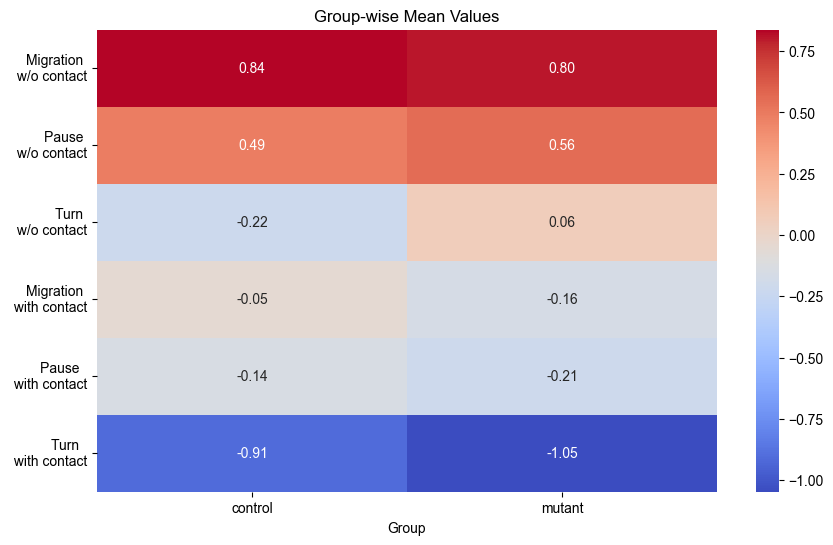

In [123]:
df = pd.read_csv('./csvs/reinforcement_results/policy_results_frame5_alldata.csv')

policy_results_df = pd.DataFrame(results)
policy_results_df.columns = ['Group','Filename','ID','Migration \n w/o contact',
                             'Pause \n w/o contact',
                             'Turn \n w/o contact',
                             'Migration \n with contact',
                             'Pause  \n with contact',
                             'Turn  \n with contact']

#数値部分だけを正規化
numeric_columns = policy_results_df.columns[3:]  
opt_policies_norm = policy_results_df[numeric_columns].div(policy_results_df[numeric_columns].max(axis=1), axis=0)

# 正規化後のデータフレームに非数値列を追加
opt_policies_norm['Group'] = policy_results_df['Group']
#opt_policies_norm['ID'] = policy_results_df['ID']
#opt_policies_norm['Filename'] = policy_results_df['Filename']

summary = opt_policies_norm.groupby('Group').mean().T  # 平均

import matplotlib.pyplot as plt
import seaborn as sns

# グループごとの平均値のヒートマップ
plt.figure(figsize=(10, 6))
sns.heatmap(summary, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Group-wise Mean Values")
plt.show()




In [112]:
policy_results_df = pd.DataFrame(results)
policy_results_df.columns = ['Group','ID','Filename','Migration \n w/o contact',
                             'Pause \n w/o contact',
                             'Turn \n w/o contact',
                             'Migration \n with contact',
                             'Pause  \n with contact',
                             'Turn  \n with contact']

#数値部分だけを正規化
numeric_columns = policy_results_df.columns[3:]  
opt_policies_norm = policy_results_df[numeric_columns].div(policy_results_df[numeric_columns].max(axis=1), axis=0)

# 正規化後のデータフレームに非数値列を追加
opt_policies_norm['Group'] = policy_results_df['Group']
opt_policies_norm['ID'] = policy_results_df['ID']

In [120]:
opt_policies_norm.iloc[50:100]

,Migration \n w/o contact,Pause \n w/o contact,Turn \n w/o contact,Migration \n with contact,Pause \n with contact,Turn \n with contact,Group,ID
50,1.000000,0.169799,0.050749,0.066755,-0.417016,-0.870287,mutant,0
51,1.000000,0.579371,-0.014370,-0.177089,0.000574,-1.388486,mutant,1
52,1.000000,0.713485,0.368997,-0.310909,-0.467981,-1.303592,mutant,2
53,1.000000,0.363028,0.218926,0.277845,0.076657,-1.936457,mutant,3
54,1.000000,0.908849,0.244261,-0.121157,-0.386714,-1.645239,mutant,4
55,1.000000,0.610440,-0.057328,0.160033,-0.268322,-1.444824,mutant,5
56,1.000000,0.584289,0.092276,0.062248,-0.679889,-1.058923,mutant,6
57,1.000000,0.178756,0.116744,0.426286,0.103813,-1.825599,mutant,7
58,1.000000,0.657413,0.089798,0.149277,-0.635568,-1.260920,mutant,8
59,1.000000,0.448982,0.244579,0.009508,-0.501360,-1.201710,mutant,9


In [124]:
opt_policies_norm.iloc[80]

Migration \n w/o contact    -0.333293
Pause \n w/o contact         0.333173
Turn \n w/o contact               1.0
Migration \n with contact   -0.333293
Pause  \n with contact      -0.333293
Turn  \n with contact       -0.333293
Group                          mutant
Name: 80, dtype: object

In [125]:
policy_results_df.iloc[80]

Group                                    mutant
Filename                     nagoya_D4-3_L8.csv
ID                                            0
Migration \n w/o contact               -1.03155
Pause \n w/o contact                   1.031177
Turn \n w/o contact                    3.095022
Migration \n with contact              -1.03155
Pause  \n with contact                 -1.03155
Turn  \n with contact                  -1.03155
Name: 80, dtype: object

In [126]:
np.argmax(opt_policies_norm['Turn \n w/o contact'])

23

In [146]:
policy_results_df.iloc[(np.array(np.where(opt_policies_norm['Turn \n w/o contact'] == opt_policies_norm['Turn \n w/o contact'].max()))[0].tolist())]

,Group,Filename,ID,Migration \n w/o contact,Pause \n w/o contact,Turn \n w/o contact,Migration \n with contact,Pause \n with contact,Turn \n with contact
23,mutant,nagoya_D4-4_L7.csv,3,-1.104532,2.034613,2.383515,-1.104532,-1.104532,-1.104532
80,mutant,nagoya_D4-3_L8.csv,0,-1.031550,1.031177,3.095022,-1.031550,-1.031550,-1.031550
141,mutant,nagoya_D4-1_L10.csv,1,0.777071,1.708246,2.430337,-1.638551,-1.638551,-1.638551
145,mutant,nagoya_D4-1_L10.csv,5,-1.209671,1.713799,3.124887,-1.209671,-1.209671,-1.209671
146,mutant,nagoya_D4-1_L10.csv,6,1.057866,1.292936,1.711836,-1.162287,-1.645184,-1.255167
148,mutant,nagoya_D4-1_L10.csv,8,1.098907,0.083592,1.352968,0.083592,-1.591125,-1.027933
153,mutant,nagoya_D4-5_L8.csv,3,-0.687409,0.720549,2.029087,-0.687409,-0.687409,-0.687409
159,mutant,nagoya_D4-5_L8.csv,9,-0.182574,-0.182574,0.912871,-0.182574,-0.182574,-0.182574
176,mutant,nagoya_D4-2_L9.csv,6,0.032642,2.582637,3.199135,-1.938138,-1.938138,-1.938138
231,control,nagoya_C4-4_L10.csv,1,-0.866422,0.585750,1.964108,0.294827,0.020330,-1.998593


In [147]:
policy_results_df.iloc[141:150]

,Group,Filename,ID,Migration \n w/o contact,Pause \n w/o contact,Turn \n w/o contact,Migration \n with contact,Pause \n with contact,Turn \n with contact
141,mutant,nagoya_D4-1_L10.csv,1,0.777071,1.708246,2.430337,-1.638551,-1.638551,-1.638551
142,mutant,nagoya_D4-1_L10.csv,2,2.021402,-0.045099,0.577744,0.211185,-0.832613,-1.932619
143,mutant,nagoya_D4-1_L10.csv,3,2.260261,1.715276,-0.488652,-0.488652,-1.791307,-1.206926
144,mutant,nagoya_D4-1_L10.csv,4,2.222942,1.260875,-0.072228,-0.460055,-1.778689,-1.172846
145,mutant,nagoya_D4-1_L10.csv,5,-1.209671,1.713799,3.124887,-1.209671,-1.209671,-1.209671
146,mutant,nagoya_D4-1_L10.csv,6,1.057866,1.292936,1.711836,-1.162287,-1.645184,-1.255167
147,mutant,nagoya_D4-1_L10.csv,7,0.579628,0.945764,0.724105,-0.575292,-0.186056,-1.488148
148,mutant,nagoya_D4-1_L10.csv,8,1.098907,0.083592,1.352968,0.083592,-1.591125,-1.027933
149,mutant,nagoya_D4-1_L10.csv,9,1.543546,0.957673,1.362143,-0.933902,-1.464730,-1.464730


# 新たなTodrov論文で実装してみる。

In [80]:
df_control = pd.read_csv('./csvs/trajectory/C1_L10.csv')
df_mutant = pd.read_csv('./csvs/trajectory/D1_L10.csv')

In [82]:
def create_kalman_filter(x, y):
    """
    カルマンフィルタを初期化します。
    """
    kf = KalmanFilter(initial_state_mean=[x, y, 0, 0],
                      transition_matrices=[[1, 0, 1, 0],
                                           [0, 1, 0, 1],
                                           [0, 0, 1, 0],
                                           [0, 0, 0, 1]],
                      observation_matrices=[[1, 0, 0, 0],
                                            [0, 1, 0, 0]],
                      transition_covariance=0.01 * np.eye(4),
                      observation_covariance=10.0 * np.eye(2),
                      initial_state_covariance=100.0 * np.eye(4))
    return kf

def calculate_angle_between_vectors(T, m, H):
    """
    Calculates the angle θ between the vectors Tm_g and m_gH using vector math.

    Parameters:
    T (np.array): Coordinates of the Tail (T) [x, y].
    m (np.array): Coordinates of the Mid (m) [x, y].
    H (np.array): Coordinates of the Head (H) [x, y].

    Returns:
    float: Angle θ in degrees.
    """
    # Calculate vectors Tm_g and m_gH
    T_mg = m - T  # Vector from Tail to Mid: Tm_g = m - T
    mg_H = H - m  # Vector from Mid to Head: m_gH = H - m

    # Calculate the dot product of the vectors
    dot_product = np.dot(T_mg, mg_H)

    # Calculate magnitudes (norms) of the vectors
    magnitude_T_mg = np.linalg.norm(T_mg)
    magnitude_mg_H = np.linalg.norm(mg_H)

    # Check for zero magnitude to avoid division by zero
    if magnitude_T_mg == 0 or magnitude_mg_H == 0:
        return np.nan

    # Calculate the cosine of the angle using the dot product formula
    cos_theta = dot_product / (magnitude_T_mg * magnitude_mg_H)

    # Clip cos_theta to avoid potential numerical issues outside [-1, 1]
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    # Calculate the angle in radians and then convert to degrees
    theta = np.arccos(cos_theta)  # Radians
    theta_degrees = np.degrees(theta)  # Convert to degrees

    return theta_degrees



def smooth_trajectory_with_flip_correction(data):
    """
    ラルバのトラッキングデータに対してカルマンフィルタとスプライン補間を適用し、
    Head, Middle, Tail の座標を平滑化し、進行方向に基づいて Head と Tail を修正します。
    最後に Smoothed_Angle を計算します。

    Parameters:
        data (pd.DataFrame): トラッキングデータ。必要な列:
            ['ID', 'Frame', 'Middle_X', 'Middle_Y', 'Head_X', 'Head_Y', 'Tail_X', 'Tail_Y']

    Returns:
        pd.DataFrame: 平滑化されたデータ、修正後の Head/Tail、および 'Smoothed_Angle' を含むデータフレーム。
    """
    data = data.copy()
    ids = data['ID'].unique()
    smoothed_data = []

    for id_value in tqdm(ids, desc="Smoothing Trajectories"):
        id_data = data[data['ID'] == id_value].sort_values(by='Frame')
        frames = id_data['Frame'].values

        # 対象の列
        columns_to_smooth = ['Middle_X', 'Middle_Y', 'Head_X', 'Head_Y', 'Tail_X', 'Tail_Y']

        for col in columns_to_smooth:
            # 欠損値を線形補間で埋める
            id_data[col] = id_data[col].interpolate(method='linear', limit_direction='both')

        # 各ペア（X, Y）ごとに平滑化を適用
        smoothed_results = {}
        for pair in [('Middle_X', 'Middle_Y'), ('Head_X', 'Head_Y'), ('Tail_X', 'Tail_Y')]:
            x_col, y_col = pair
            observations = id_data[[x_col, y_col]].values

            # 観測データの形状を確認
            if observations.ndim != 2 or observations.shape[1] != 2:
                print(f"ID {id_value} の観測データ {pair} の形状が不正です。スキップします。")
                continue

            kf = create_kalman_filter(observations[0, 0], observations[0, 1])
            state_means, _ = kf.smooth(observations)

            # データポイント数を確認
            m = len(frames)
            # スプラインの次数を設定（デフォルトは3）
            k = 3
            if m <= k:
                # データポイント数が少ない場合は次数を調整
                k = m - 1 if m > 1 else 0  # k は0以上
                if k >= 1:
                    # スプライン補間を次数 k で実行
                    smoothed_x = UnivariateSpline(frames, state_means[:, 0], k=k, s=0)(frames)
                    smoothed_y = UnivariateSpline(frames, state_means[:, 1], k=k, s=0)(frames)
                else:
                    # データポイントが1つまたは0の場合、そのまま使用
                    smoothed_x = state_means[:, 0]
                    smoothed_y = state_means[:, 1]
            else:
                # データポイント数が十分な場合は通常通りスプライン補間
                smoothed_x = UnivariateSpline(frames, state_means[:, 0], s=2)(frames)
                smoothed_y = UnivariateSpline(frames, state_means[:, 1], s=2)(frames)

            # 平滑化結果を格納
            smoothed_results[x_col] = smoothed_x
            smoothed_results[y_col] = smoothed_y

        # 平滑化結果を id_data に追加
        for col in smoothed_results:
            id_data[f'Smoothed_{col}'] = smoothed_results[col]

        # 速度計算のためのシフト列を追加
        id_data['Prev_Smoothed_Middle_X'] = id_data['Smoothed_Middle_X'].shift(1)
        id_data['Prev_Smoothed_Middle_Y'] = id_data['Smoothed_Middle_Y'].shift(1)

        # 速度方向に基づいて Head と Tail を修正
        def correct_flip(row):
            # 平滑化された座標を取得
            head = np.array([row['Smoothed_Head_X'], row['Smoothed_Head_Y']])
            tail = np.array([row['Smoothed_Tail_X'], row['Smoothed_Tail_Y']])
            middle = np.array([row['Smoothed_Middle_X'], row['Smoothed_Middle_Y']])
            prev_middle = np.array([row['Prev_Smoothed_Middle_X'], row['Prev_Smoothed_Middle_Y']])
            
            velocity = middle - prev_middle
            velocity_dir = velocity / (np.linalg.norm(velocity) + 1e-10)  # 小さい値を足してゼロ除算を防止
            head_dir = (head - middle) / (np.linalg.norm(head - middle) + 1e-10)
            head_dir = (head - middle) / np.linalg.norm(head - middle)

            # ベクトルの内積で方向を確認
            if np.dot(velocity_dir, head_dir) < 0:  # 方向が逆の場合
                return pd.Series({
                    'Smoothed_Head_X': row['Smoothed_Tail_X'],
                    'Smoothed_Head_Y': row['Smoothed_Tail_Y'],
                    'Smoothed_Tail_X': row['Smoothed_Head_X'],
                    'Smoothed_Tail_Y': row['Smoothed_Head_Y'],
                })
            else:
                return pd.Series({
                    'Smoothed_Head_X': row['Smoothed_Head_X'],
                    'Smoothed_Head_Y': row['Smoothed_Head_Y'],
                    'Smoothed_Tail_X': row['Smoothed_Tail_X'],
                    'Smoothed_Tail_Y': row['Smoothed_Tail_Y'],
                })

        # Flip の修正結果を id_data に反映
        flip_corrected = id_data.apply(correct_flip, axis=1)
        id_data.update(flip_corrected)

        # Smoothed_Angle を計算
        def compute_angle(row):
            T = np.array([row['Smoothed_Tail_X'], row['Smoothed_Tail_Y']])
            m = np.array([row['Smoothed_Middle_X'], row['Smoothed_Middle_Y']])
            H = np.array([row['Smoothed_Head_X'], row['Smoothed_Head_Y']])
            return calculate_angle_between_vectors(T, m, H)

        id_data['Smoothed_Angle'] = id_data.apply(compute_angle, axis=1)

        ## Velocity を計算
        id_data['Speed'] = np.nan  # Speed カラムを初期化
    
        # 個体（ID）ごとに処理
        for id_value, group in id_data.groupby('ID'):
            group = group.sort_values(by='Frame')  # フレーム順にソート
            dx = group['Smoothed_Middle_X'].diff()  # X座標の変化量
            dy = group['Smoothed_Middle_Y'].diff()  # Y座標の変化量
            distance = np.sqrt(dx**2 + dy**2)  # 移動距離
            frame_diff = group['Frame'].diff()  # フレーム間隔
            speed = distance / frame_diff  # 距離をフレーム間隔で割る
            id_data.loc[group.index, 'Speed'] = speed  # 結果を元のデータに追加

        smoothed_data.append(id_data)

    return pd.concat(smoothed_data).reset_index(drop=True)


def detect_contact_flags(data, radius = 15):
    """
    各フレームで接触フラグを判定する。

    Parameters:
        data (pd.DataFrame): 入力データ。
        radius (float): 接触を判定する距離のしきい値。

    Returns:
        pd.Series: 接触フラグ（True/False）。
    """
    contact_flags = pd.Series(False, index=data.index)  # 初期化（全て False）
    frames = data['Frame'].unique()

    for frame in tqdm(frames, desc = 'Checking contacts...'):
        frame_data = data[data['Frame'] == frame]

        for i, row1 in frame_data.iterrows():
            id1 = row1['ID']
            head_pos1 = np.array([row1['Smoothed_Middle_X'], row1['Smoothed_Middle_Y']])

            for j, row2 in frame_data.iterrows():
                if id1 == row2['ID']:
                    continue
                body_positions = [
                    np.array([row2['Smoothed_Head_X'], row2['Smoothed_Head_Y']]),
                    np.array([row2['Smoothed_Middle_X'], row2['Smoothed_Middle_Y']]),
                    np.array([row2['Smoothed_Tail_X'], row2['Smoothed_Tail_Y']])
                ]
                distances = [np.linalg.norm(head_pos1 - pos) for pos in body_positions]
                if min(distances) <= radius:
                    contact_flags[i] = True
                    break

    return contact_flags


def judge_state(data, 
                contact_radius = 15,
                angle_threshold = 35,
                speed_threshold = 0.3,
                frame_interval = 1):
    """
    行動を分類します。
    
    Parameters:
        data (pd.DataFrame): トラッキングデータ。
        contact_radius (float): 接触の判定に使用する距離閾値。
        angle_threshold (float): ターンと判断する角度閾値。
        speed_threshold (float): 移動と判断する速度閾値。
        frame_interval (int): フレームを区切る間隔。1 にするとフレームごとの処理。
        
    Returns:
        pd.DataFrame: 各フレームの行動ラベルを含むデータフレーム。
    """
    data = data.copy()
    # ステップ1: 平滑化と Head/Tail 修正
    data_smoothed = smooth_trajectory_with_flip_correction(data)
    # ステップ2: Contact フラグを計算
    data_smoothed['Contact'] = detect_contact_flags(data_smoothed, contact_radius)
    # ステップ3: 結果を格納するリスト
    behaviors = []

    # 個体ごとに処理
    ids = data_smoothed['ID'].unique()
    for id_value in tqdm(ids, desc='Classifying Behaviors'):
        individual_data = data_smoothed[data_smoothed['ID'] == id_value].sort_values(by='Frame')
        frames = individual_data['Frame'].values
        angles = individual_data['Smoothed_Angle'].values
        speeds = individual_data['Speed'].values
        contacts = individual_data['Contact'].values

        # フレームを frame_interval ごとに間引いて処理
        for i in range(0, len(frames), frame_interval):
            if i >= len(frames):
                break  # 範囲外の場合はスキップ

            # 1フレームごとの処理
            avg_angle = angles[i]
            avg_speed = speeds[i]
            contact_flag = contacts[i]

            # 行動を分類
            if avg_angle >= angle_threshold:
                behavior = 'Turn'
            elif avg_speed >= speed_threshold:
                behavior = 'Crawl'
            else:
                behavior = 'Pause'

            # 各フレームにラベルを付ける
            behaviors.append({
                'ID': id_value, 
                'Frame': frames[i], 
                'contact_flag': int(contact_flag), 
                'state': behavior
            })
            
    # ステップ4: 結果をデータフレームにまとめる
    behavior_df = pd.DataFrame(behaviors)

    return behavior_df


## 時系列データの作成

In [83]:
behavior_df = judge_state(df_mutant,
                         frame_interval=5)
behavior_df['contact_and_state'] = behavior_df['contact_flag'].astype(str) + '_' + behavior_df['state']

contact_and_state_mapping = {
    '0_Crawl': 0,
    '0_Turn': 1,
    '0_Pause': 2,
    '1_Crawl': 3,
    '1_Turn': 4,
    '1_Pause': 5
}

state_mapping = {
    'Crawl': 0,
    'Turn': 1,
    'Pause': 2,
}

behavior_df['contact_and_state_num'] = behavior_df['contact_and_state'].map(contact_and_state_mapping)
behavior_df['state_num'] = behavior_df['state'].map(state_mapping)

Smoothing Trajectories: 100%|█| 10/10 [00:54<00:00,  5.4
Checking contacts...: 100%|█| 6000/6000 [00:24<00:00, 24
Classifying Behaviors: 100%|█| 10/10 [00:00<00:00, 661.3


In [86]:
behavior_df[behavior_df.ID == 1]

,ID,Frame,contact_flag,state,contact_and_state,contact_and_state_num,state_num
0,1,0,0,Pause,0_Pause,2,2
1,1,5,0,Crawl,0_Crawl,0,0
2,1,10,0,Crawl,0_Crawl,0,0
3,1,15,0,Crawl,0_Crawl,0,0
4,1,20,1,Crawl,1_Crawl,3,0
...,...,...,...,...,...,...,...
1008,1,5885,0,Crawl,0_Crawl,0,0
1009,1,5890,0,Crawl,0_Crawl,0,0
1010,1,5985,0,Crawl,0_Crawl,0,0
1011,1,5990,0,Crawl,0_Crawl,0,0


## 遷移確率行列の構成

In [94]:
def compute_transition_matrices(data, states):
    """
    非接触 (c=0) と接触 (c=1) の遷移確率行列を計算
    """
    transition_counts_c0 = Counter()
    transition_counts_c1_c0 = Counter()
    transition_counts_c1_c1 = Counter()
    state_counts_c0 = Counter()
    state_counts_c1 = Counter()
    
    for idx in range(len(data) - 1):
        s_prev = data.iloc[idx]["state_num"]
        s_next = data.iloc[idx + 1]["state_num"]
        c_prev = data.iloc[idx]["contact_flag"]
        c_next = data.iloc[idx + 1]["contact_flag"]
        
        if c_prev == 0:  # 非接触時
            transition_counts_c0[(s_prev, s_next)] += 1
            state_counts_c0[s_prev] += 1
        elif c_prev == 1:  # 接触時
            if c_next == 0:
                transition_counts_c1_c0[(s_prev, s_next)] += 1
            elif c_next == 1:
                transition_counts_c1_c1[(s_prev, s_next)] += 1
            state_counts_c1[s_prev] += 1
    
    # 行列を構築
    P_c0 = np.zeros((len(states), len(states)))
    P_c1_c0 = np.zeros((len(states), len(states)))
    P_c1_c1 = np.zeros((len(states), len(states)))
    
    for (s, s_next), count in transition_counts_c0.items():
        P_c0[s, s_next] = count / state_counts_c0[s]
    
    for (s, s_next), count in transition_counts_c1_c0.items():
        P_c1_c0[s, s_next] = count / state_counts_c1[s]
    
    for (s, s_next), count in transition_counts_c1_c1.items():
        P_c1_c1[s, s_next] = count / state_counts_c1[s]
    
    return P_c0, P_c1_c0, P_c1_c1


In [95]:
def negative_log_likelihood(v, P_c0, P_c1_c0, P_c1_c1, data, states):
    """
    負の対数尤度関数
    """
    v = np.array(v)
    z = np.exp(-v)  # desirability function
    log_likelihood = 0
    
    for idx in range(len(data) - 1):
        s_prev = data.iloc[idx]["state_num"]
        s_next = data.iloc[idx + 1]["state_num"]
        c_prev = data.iloc[idx]["contact_flag"]
        
        if c_prev == 0:  # 非接触時
            P_current = P_c0[s_prev, :]
        elif c_prev == 1:  # 接触時
            # 接触時の遷移確率
            P_contact = P_c1_c0[s_prev, :] + P_c1_c1[s_prev, :]
            P_current = P_contact * z
            sum_P_current = np.sum(P_current)
            if sum_P_current > 0:
                P_current /= sum_P_current
            else:
                P_current[:] = 1 / len(states)  # 一様分布に置き換え

        # 対数尤度を計算
        if P_current[s_next] > 0:
            log_likelihood += np.log(P_current[s_next])
        else:
            log_likelihood += np.log(1e-10)  # 極小値で代用
    
    return -log_likelihood  # 負の対数尤度


##  最適化

In [96]:
# 基本状態リスト (3状態)
states = sorted(behavior_df["state_num"].unique())

# 確率遷移行列を計算
P_c0, P_c1_c0, P_c1_c1 = compute_transition_matrices(behavior_df, states)

print("非接触時 (次も非接触) の遷移確率行列:")
print(P_c0)
print("接触時 (次も非接触) の遷移確率行列:")
print(P_c1_c0)
print("接触時 (次も接触) の遷移確率行列:")
print(P_c1_c1)

非接触時 (次も非接触) の遷移確率行列:
[[    0.82579    0.088015    0.086195]
 [    0.13051     0.83748    0.032011]
 [    0.19687     0.13299     0.67014]]
接触時 (次も非接触) の遷移確率行列:
[[    0.20249     0.05296    0.031153]
 [   0.036638     0.19612    0.010776]
 [   0.059701    0.014925     0.14925]]
接触時 (次も接触) の遷移確率行列:
[[     0.5296     0.11526    0.068536]
 [   0.064655     0.67241    0.019397]
 [    0.32836     0.13433     0.31343]]


### 全部のデータで最適化

In [ ]:

# 初期値 (v を 0 に初期化)
v_init = np.zeros(len(states))  # 基本状態の価値関数は3つ

# 最適化
result = minimize(
    negative_log_likelihood,
    v_init,
    args=(P_passive, behavior_df, states),
    method="BFGS"
)

# 推定された価値関数
v_estimated = result.x
print("推定された価値関数 v(s):", v_estimated)

### passive data での最適化

In [97]:
# passive data
# 非接触 (c=0) データのフィルタリング
passive_data = behavior_df[behavior_df["contact_flag"] == 0]

# 初期値 (v を 0 に初期化)
v_init = np.zeros(len(states))  # 基本状態の価値関数は3つ

# 最適化
result_passive = minimize(
    negative_log_likelihood,
    v_init,
    args=(P_c0, P_c1_c0, P_c1_c1, passive_data, states),
    method="BFGS"
)

# 推定された価値関数
v_passive_estimated = result_passive.x
print("推定された価値関数 v(s):", v_passive_estimated)

推定された価値関数 v(s): [          0           0           0]


### contact dataでの最適化

In [98]:
# passive datar
# 非接触 (c=0) データのフィルタリング
contact_data = behavior_df[behavior_df["contact_flag"] == 1]

# 初期値 (v を 0 に初期化)
v_init = np.zeros(len(states))  # 基本状態の価値関数は3つ

# 最適化
result_contact = minimize(
    negative_log_likelihood,
    v_init,
    args=(P_c0, P_c1_c0, P_c1_c1, contact_data, states),
    method="BFGS"
)

# 推定された価値関数
v_contact_estimated = result_contact.x
print("推定された価値関数 v(s):", v_contact_estimated)

推定された価値関数 v(s): [  -0.088923   -0.022995     0.11284]


## Plot

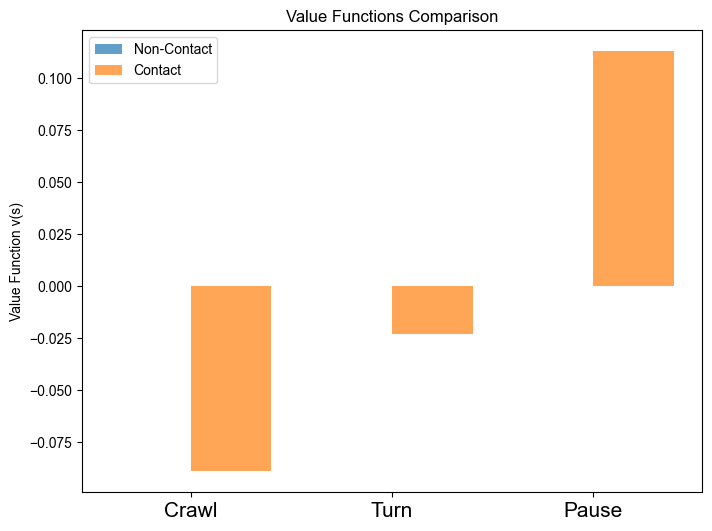

In [99]:
# 比較
states_labels = ['Crawl', 'Turn', 'Pause']
diff = v_contact_estimated - v_passive_estimated

# 可視化
plt.figure(figsize=(8, 6))
x = np.arange(len(states))
plt.bar(x - 0.2, v_passive_estimated, width=0.4, label='Non-Contact', alpha=0.7)
plt.bar(x + 0.2, v_contact_estimated, width=0.4, label='Contact', alpha=0.7)
plt.xticks(x, states_labels, fontsize = 15)
plt.ylabel("Value Function v(s)")
plt.title("Value Functions Comparison")
plt.legend()
plt.show()

# 関数化

In [2]:
def calculate_value_funcs(path):
    flatten = lambda x: [z for y in x for z in (flatten(y) if hasattr(y, '__iter__') and not isinstance(y, str) else (y,))]

    df = pd.read_csv(path)
    behavior_df = judge_state(df,
                         frame_interval=5)
    behavior_df['contact_and_state'] = behavior_df['contact_flag'].astype(str) + '_' + behavior_df['state']
    
    contact_and_state_mapping = {
        '0_Crawl': 0,
        '0_Turn': 1,
        '0_Pause': 2,
        '1_Crawl': 3,
        '1_Turn': 4,
        '1_Pause': 5
    }
    
    state_mapping = {
        'Crawl': 0,
        'Turn': 1,
        'Pause': 2,
    }
    
    behavior_df['contact_and_state_num'] = behavior_df['contact_and_state'].map(contact_and_state_mapping)
    behavior_df['state_num'] = behavior_df['state'].map(state_mapping)
    # state全部
    states = sorted(behavior_df["state_num"].unique())
    results = []
    plt.figure(figsize=(35, 35))
    for id_ in sorted(behavior_df['ID'].unique()):
        # IDによる選別
        data = behavior_df[behavior_df.ID == id_]
        
        # 確率遷移行列を計算
        P_c0, P_c1_c0, P_c1_c1 = compute_transition_matrices(data, states)
        # passive data
        # 非接触 (c=0) データのフィルタリング
        passive_data = data[data["contact_flag"] == 0]
        # 初期値 (v を 0 に初期化)
        v_init = np.zeros(len(states))  # 基本状態の価値関数は3つ
        # 最適化
        result_passive = minimize(
            negative_log_likelihood,
            v_init,
            args=(P_c0, P_c1_c0, P_c1_c1, passive_data, states),
            method="BFGS"
        )
        # 推定された価値関数
        v_passive_estimated = result_passive.x
        # contact data
        contact_data = data[data["contact_flag"] == 1]
        
        # 初期値 (v を 0 に初期化)
        v_init = np.zeros(len(states))  # 基本状態の価値関数は3つ
        # 最適化
        result_contact = minimize(
            negative_log_likelihood,
            v_init,
            args=(P_c0, P_c1_c0, P_c1_c1, contact_data, states),
            method="BFGS"
        )
        
        # 推定された価値関数
        v_contact_estimated = result_contact.x
    
        states_labels = ['Crawl', 'Turn', 'Pause']
        filename = os.path.basename(path)
        
        # 可視化
        plt.subplot(3,4,id_)
        x = np.arange(len(states))
        plt.bar(x - 0.2, v_passive_estimated, width=0.4, label='Non-Contact', alpha=0.7)
        plt.bar(x + 0.2, v_contact_estimated, width=0.4, label='Contact', alpha=0.7)
        plt.xticks(x, states_labels, fontsize = 15)
        plt.ylabel("Value Function v(s)", fontsize = 15)
        plt.title(f"Path:{filename} ID:{id_}\n Value Functions Comparison", fontsize = 20)
        plt.legend()


        results.append(flatten([filename, id_, v_passive_estimated.tolist(), v_contact_estimated.tolist()]))

    return results, pd.DataFrame(results)


Classifying Behaviors: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 716.25it/s]


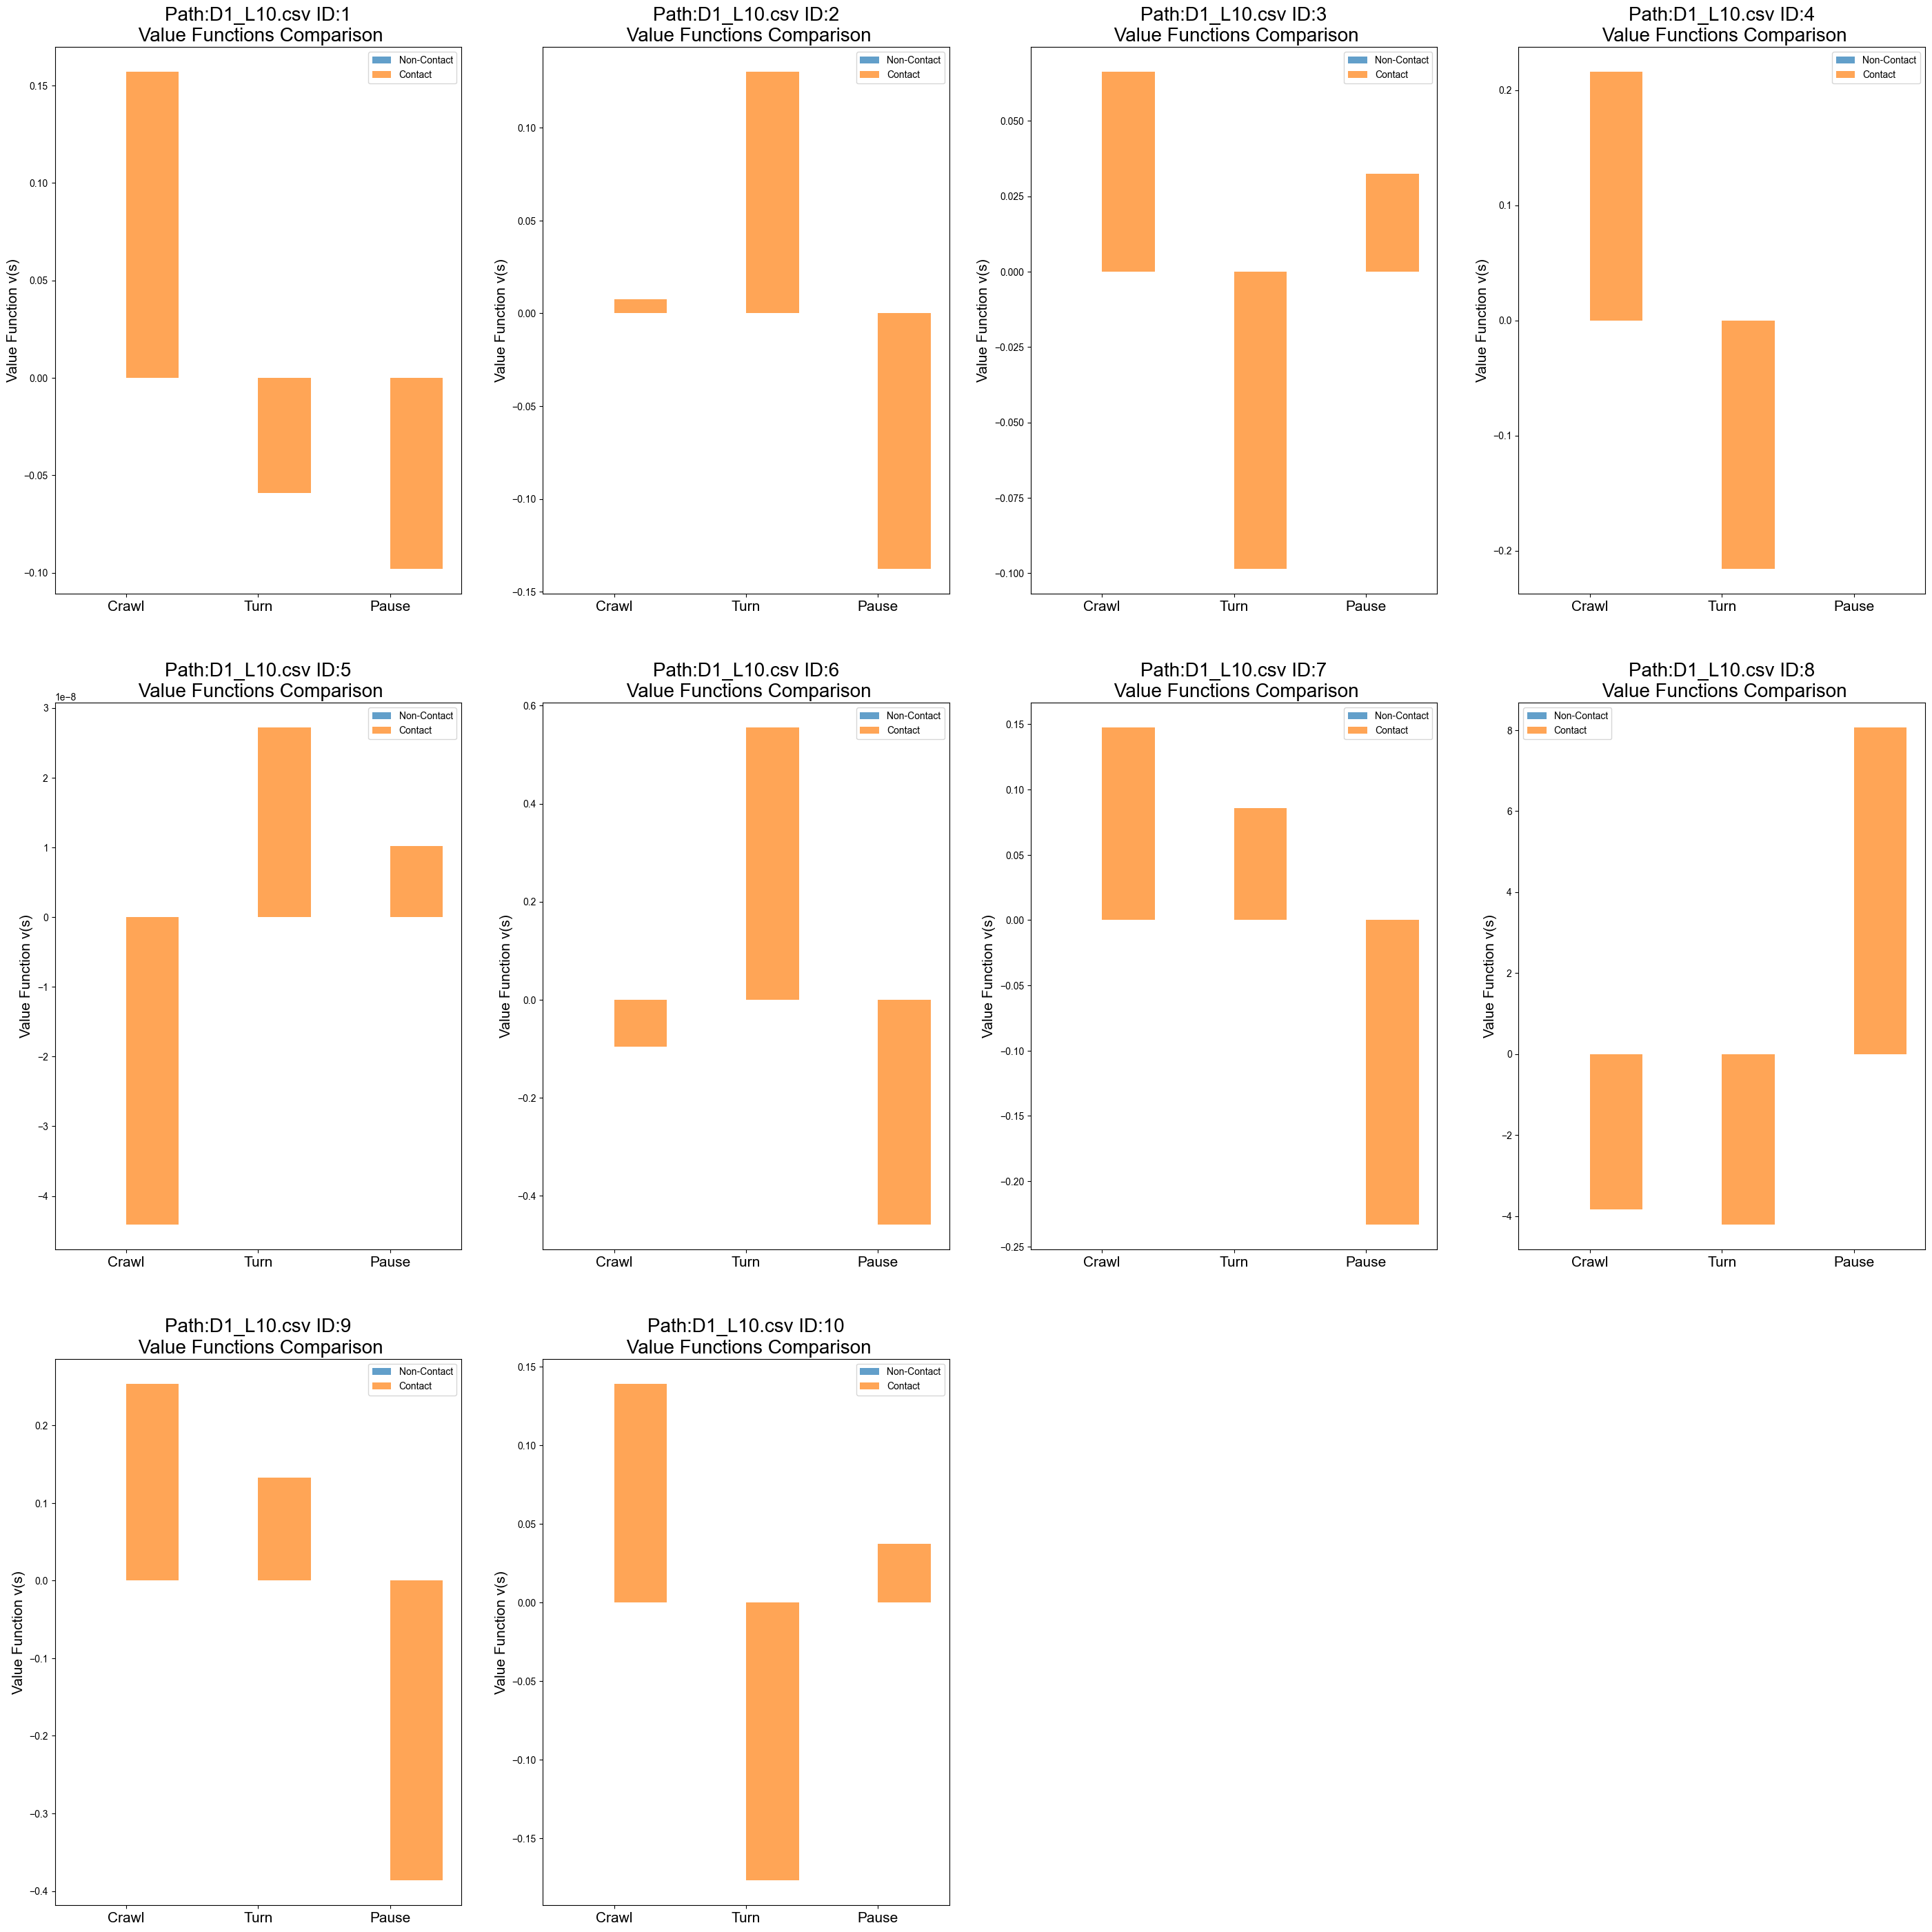

In [3]:
results_list, results_dataframe = calculate_value_funcs('./csvs/trajectory/D1_L10.csv')

Smoothing Trajectories: 100%|█| 10/10 [00:55<00:00,  5.5
Checking contacts...: 100%|█| 6000/6000 [00:24<00:00, 24
Classifying Behaviors: 100%|█| 10/10 [00:00<00:00, 686.3


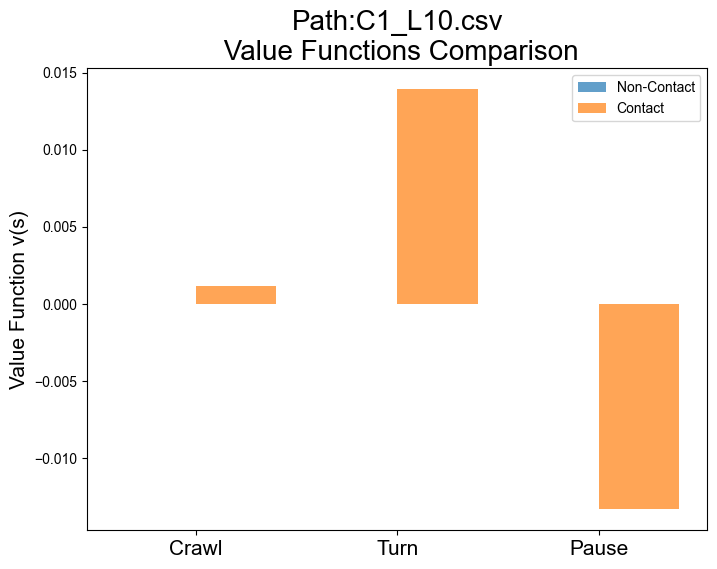

In [103]:
v_passive_estimated, v_contact_estimated = calculate_value_funcs('./csvs/trajectory/C1_L10.csv')

## glob

In [ ]:
flatten = lambda x: [z for y in x for z in (flatten(y) if hasattr(y, '__iter__') and not isinstance(y, str) else (y,))]
from tqdm import tqdm
from natsort import natsorted

mutants_results_dfs = pd.DataFrame()
for path in tqdm(natsorted(glob.glob('./csvs/trajectory/D*.csv'))):
    _, results_dataframe = calculate_value_funcs(path)
    mutants_results_dfs = pd.concat([mutants_results_dfs,results_dataframe])


control_results_dfs = pd.DataFrame()
for path in tqdm(natsorted(glob.glob('./csvs/trajectory/C*.csv'))):
    _, results_dataframe = calculate_value_funcs(path)
    control_results_dfs = pd.concat([control_results_dfs,results_dataframe])
  


### Plot

(-1.0, 1.0)

<Figure size 1000x1000 with 0 Axes>

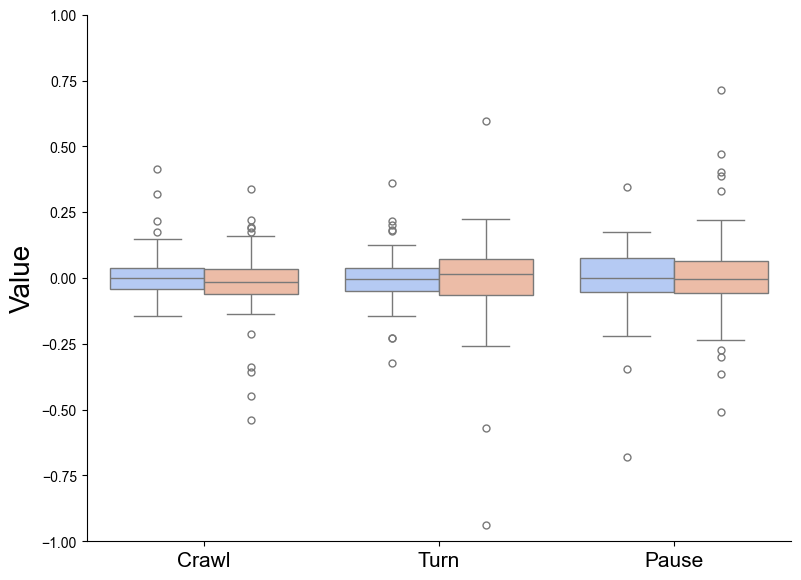

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
# フォントの設定を Arial に変更
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'


df_mutant = pd.read_csv('./csvs/reinforce_results/mutants_results_calculatingnow.csv', index_col= 0 )
df_mutant.columns = ['filename','id',
                     'non_contact_crawl','non_contact_turn','non_contact_pause',
                     'contact_crawl','contact_turn','contact_pause']
df_mutant['group'] = 'mutant'
df_control = pd.read_csv('./csvs/reinforce_results/control_results_calculatingnow.csv', index_col= 0 )
df_control.columns = ['filename','id',
                     'non_contact_crawl','non_contact_turn','non_contact_pause',
                     'contact_crawl','contact_turn','contact_pause']
df_control['group'] = 'control'
df = pd.concat([df_mutant,df_control])
df_compare = df[df.columns[5:]]
df_compare_melt = df_compare.melt(id_vars="group", var_name="contact_type", value_name="value")

plt.figure(figsize=(10,10))
grped_bplot = sns.catplot(x='contact_type', y='value',
                data=df_compare_melt, kind="box",
                hue = 'group',
            palette="coolwarm",
            legend=False,
            height=6, aspect=1.3);
# make grouped stripplot
# grped_bplot = sns.stripplot(x='contact_type', y='value', 
#               data=df_compare_melt, 
#               hue = 'group',
#               palette="coolwarm",
#               marker='o', 
#               alpha=0.5)
plt.xticks([0,1,2],['Crawl','Turn','Pause'],fontsize = 15)
plt.xlabel('',fontsize = 20)
plt.ylabel('Value',fontsize = 20)
plt.ylim([-1,1])

### 0でFiltering

/tmp/ipykernel_102/2117629332.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['group'] = df_filtered['group'].map({'control':'$white^{1118}$',


(-1.0, 1.0)

<Figure size 1000x1000 with 0 Axes>

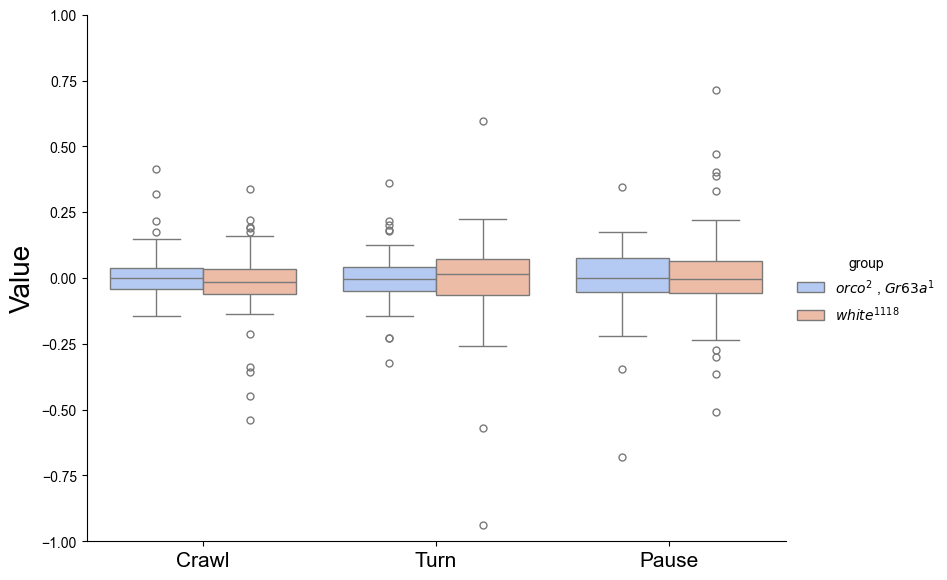

In [6]:
df_mutant = pd.read_csv('./csvs/reinforce_results/mutants_results_calculatingnow.csv', index_col= 0 )
df_mutant.columns = ['filename','id',
                     'non_contact_crawl','non_contact_turn','non_contact_pause',
                     'contact_crawl','contact_turn','contact_pause']
df_mutant['group'] = 'mutant'
df_control = pd.read_csv('./csvs/reinforce_results/control_results_calculatingnow.csv', index_col= 0 )
df_control.columns = ['filename','id',
                     'non_contact_crawl','non_contact_turn','non_contact_pause',
                     'contact_crawl','contact_turn','contact_pause']
df_control['group'] = 'control'
df = pd.concat([df_mutant,df_control])
df_compare = df[df.columns[5:]]
# Remove rows where all contact metrics are zero
df_filtered = df_compare[(df_compare[['contact_crawl', 'contact_turn', 'contact_pause']] != 0).any(axis=1)]

df_filtered['group'] = df_filtered['group'].map({'control':'$white^{1118}$',
                                                'mutant':'$orco^2$ , $Gr63a^1$',})

df_filtered_melt = df_filtered.melt(id_vars="group", var_name="contact_type", value_name="value")

plt.figure(figsize=(10,10))
grped_bplot = sns.catplot(x='contact_type', y='value',
                data=df_filtered_melt, kind="box",
                hue = 'group',
            palette="coolwarm",
            legend=True,
            height=6, aspect=1.3);
# make grouped stripplot
# grped_bplot = sns.stripplot(x='contact_type', y='value', 
#               data=df_filtered_melt, 
#               hue = 'group',
#               palette="coolwarm",
#               marker='o', 
#               alpha=0.5)
plt.xticks([0,1,2],['Crawl','Turn','Pause'],fontsize = 15)
plt.xlabel('',fontsize = 20)
plt.ylabel('Value',fontsize = 20)
plt.ylim([-1,1])

#### mean

Text(1279.3864267676765, 0.5, '')

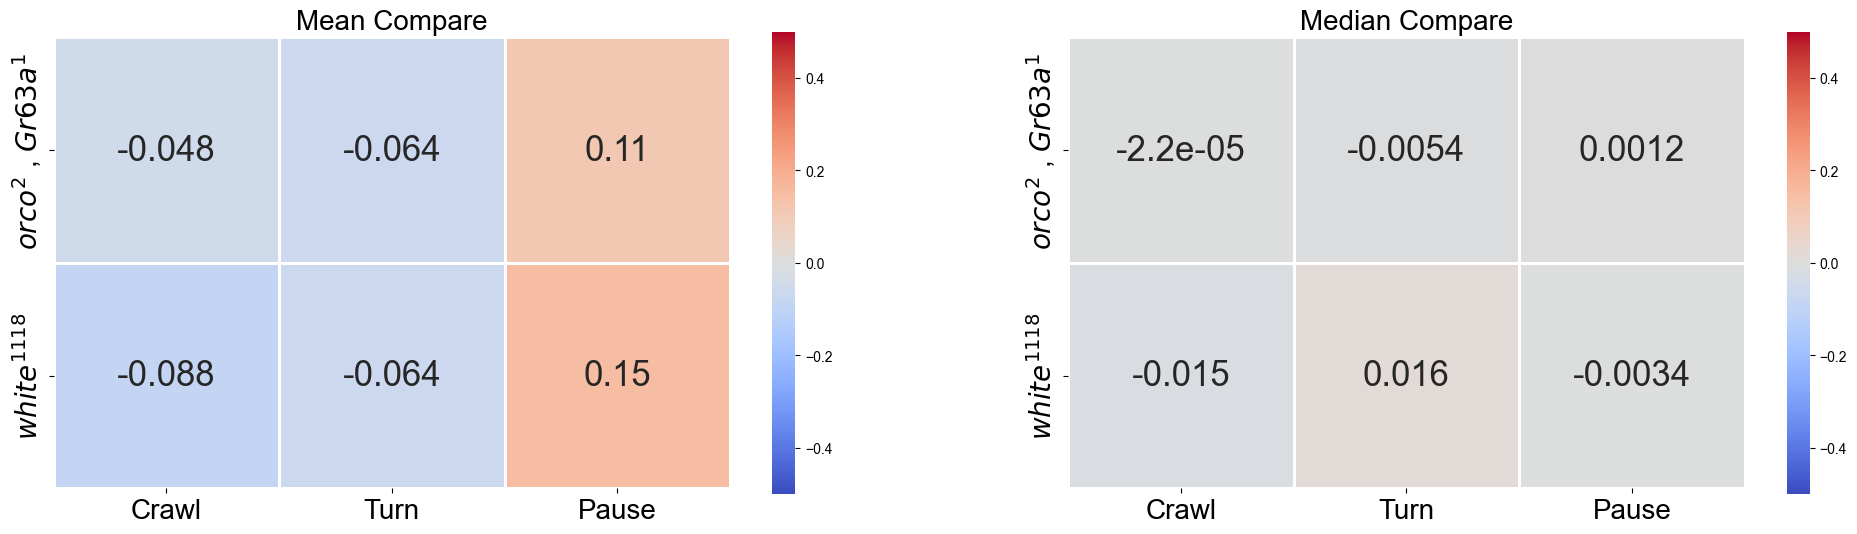

In [7]:
df_filtered_mean = df_filtered.groupby('group').mean()

plt.figure(figsize = (24,6))
plt.subplot(121)
sns.heatmap(df_filtered_mean,
            vmax = 0.5,
            vmin = -0.5,
            annot = True,
            cmap = 'coolwarm',
            xticklabels=['Crawl','Turn','Pause'],
            annot_kws={"size":25},
            linewidth = 2,
            #linecolor = 'k', 
            square=True
           )
plt.title('Mean Compare', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.ylabel('')

df_filtered_median = df_filtered.groupby('group').median()

plt.subplot(122)
sns.heatmap(df_filtered_median,
            annot = True,
            vmax = 0.5,
            vmin = -0.5,
            cmap = 'coolwarm',
            xticklabels=['Crawl','Turn','Pause'],
            annot_kws={"size":25},
            linewidth = 2,
            #linecolor = 'k', 
            square=True
           )
plt.title('Median Compare', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.ylabel('')

Text(0.5, 0, 'Mean of Value Function')

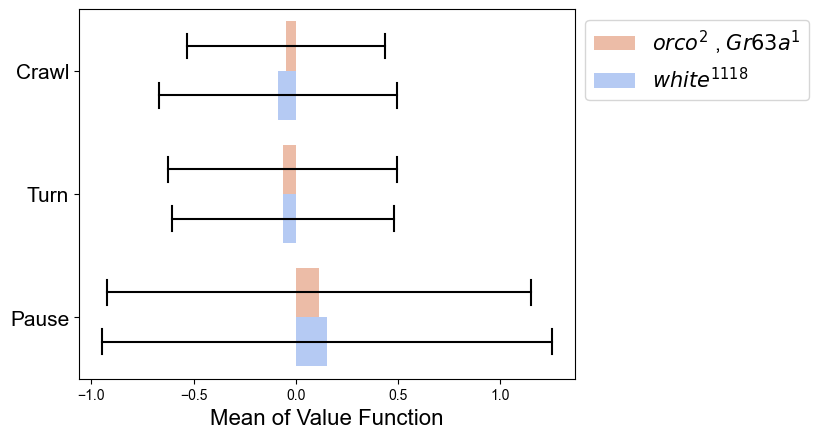

In [8]:

df_filtered_melt = df_filtered.melt(id_vars="group", var_name="contact_type", value_name="value")

fig,ax=plt.subplots()
sns.barplot(data = df_filtered_melt,
            x='value', 
            y='contact_type',
            orient = 'y',
            errorbar=("sd"), capsize=.4,
            err_kws={"color": "k", "linewidth": 1.5},
            linewidth=0, 
            palette = 'coolwarm_r',
            hue = 'group',
           )
handler, label = ax.get_legend_handles_labels()
ax.legend(handler, ["$orco^2$ , $Gr63a^1$","$white^{1118}$"],
          fontsize = 15,
          loc='upper left',bbox_to_anchor=(1.0,1))
plt.yticks([0,1,2],['Crawl','Turn','Pause'],fontsize = 15)
plt.ylabel('')
plt.xticks(fontsize = 10)
plt.xlabel('Mean of Value Function', fontsize = 16)
#plt.savefig('./Fig_paper/reinfo_valuefunc_mean_barplot_se.pdf')

In [48]:
df_filtered['group'].map({'mutant':'$orco^2$ , $Gr63a^1$',
                 'control':'$white^{1118}$'})

0    $orco^2$ , $Gr63a^1$
1    $orco^2$ , $Gr63a^1$
2    $orco^2$ , $Gr63a^1$
3    $orco^2$ , $Gr63a^1$
4    $orco^2$ , $Gr63a^1$
             ...         
4          $white^{1118}$
5          $white^{1118}$
7          $white^{1118}$
0          $white^{1118}$
5          $white^{1118}$
Name: group, Length: 305, dtype: object

In [8]:
df_filtered_mean

,contact_crawl,contact_turn,contact_pause
group,,,
control,-0.241990,-0.171395,0.413382
mutant,-0.328894,0.014776,0.314104


#### median

Text(0.5, 0.98, 'Without Filtering')

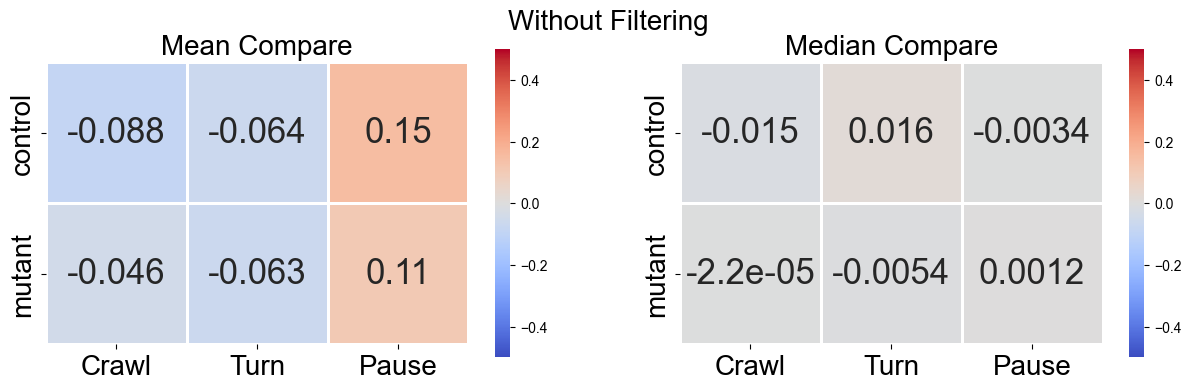

In [12]:
df_filtered_mean = df_compare.groupby('group').mean()

plt.figure(figsize = (15,4))
plt.subplot(121)
sns.heatmap(df_filtered_mean,
            vmax = 0.5,
            vmin = -0.5,
            annot = True,
            cmap = 'coolwarm',
            xticklabels=['Crawl','Turn','Pause'],
            annot_kws={"size":25},
            linewidth = 2,
            #linecolor = 'k', 
            square=True
           )
plt.title('Mean Compare', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.ylabel('')

df_filtered_median = df_filtered.groupby('group').median()

plt.subplot(122)
sns.heatmap(df_filtered_median,
            annot = True,
            vmax = 0.5,
            vmin = -0.5,
            cmap = 'coolwarm',
            xticklabels=['Crawl','Turn','Pause'],
            annot_kws={"size":25},
            linewidth = 2,
            #linecolor = 'k', 
            square=True
           )
plt.title('Median Compare', fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.ylabel('')
plt.suptitle('Without Filtering', fontsize = 20)

## 6000 Frameのものでやってみる。

In [9]:
fullframe_list = []
for path in tqdm(natsorted(glob.glob('./csvs/trajectory/*.csv'))):
    df_full_frame = pd.read_csv(path)
    if df_full_frame.Frame.max() > 5500:
        fullframe_list.append(os.path.basename(path))
fullframe_list

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 71.96it/s]


['C1_L10.csv',
 'C2_L9.csv',
 'C3_L10.csv',
 'C4-3_L9.csv',
 'C5_L10.csv',
 'C8_L10.csv',
 'C_L5_test_1.csv',
 'C_L5_test_2.csv',
 'D1_L10.csv',
 'D2_L10.csv',
 'D3_L10.csv',
 'D6_L10.csv',
 'D8_L10.csv',
 'D9_L10.csv',
 'D10_L10.csv',
 'D_L5_test_1.csv',
 'D_L5_test_2.csv']

In [10]:
df_fullframe = df[df.filename.isin(fullframe_list)]

Text(36.133502492877504, 0.5, 'Value')

<Figure size 1000x1000 with 0 Axes>

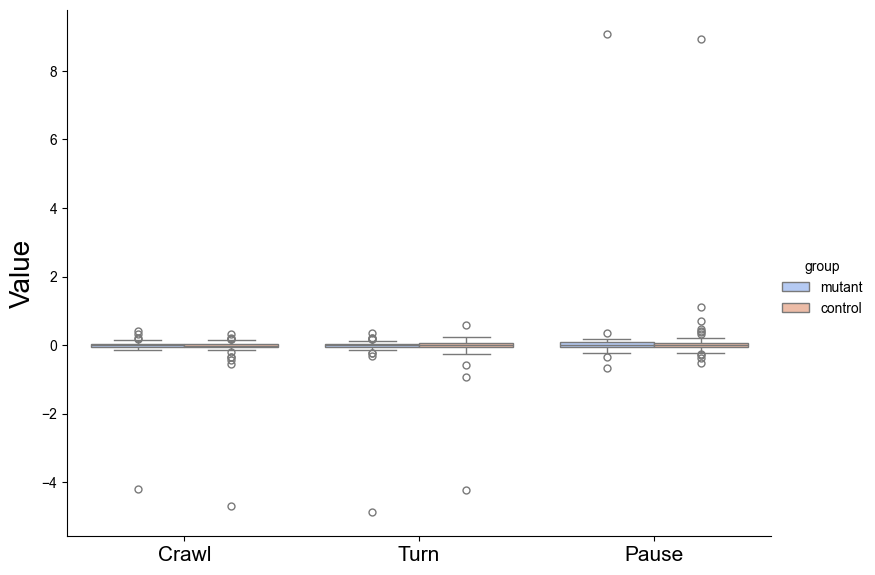

In [11]:
df_compare = df_fullframe[df_fullframe.columns[5:]]
# Remove rows where all contact metrics are zero
df_filtered = df_compare[(df_compare[['contact_crawl', 'contact_turn', 'contact_pause']] != 0).any(axis=1)]
df_filtered_melt = df_filtered.melt(id_vars="group", var_name="contact_type", value_name="value")
## df_compare_melt = df_compare.melt(id_vars="group", var_name="contact_type", value_name="value")

plt.figure(figsize=(10,10))
grped_bplot = sns.catplot(x='contact_type', y='value',
                data=df_filtered_melt, kind="box",
                hue = 'group',
            palette="coolwarm",
            legend=True,
            height=6, aspect=1.3);

# grped_bplot = sns.catplot(x='contact_type', y='value',
#                 data=df_compare_melt, kind="box",
#                 hue = 'group',
#             palette="coolwarm",
#             legend=True,
#             height=6, aspect=1.3);

plt.xticks([0,1,2],['Crawl','Turn','Pause'],fontsize = 15)
plt.xlabel('',fontsize = 20)
plt.ylabel('Value',fontsize = 20)
#plt.ylim([-1,1])

In [169]:
df_filtered.groupby('group').mean()

,contact_crawl,contact_turn,contact_pause
group,,,
control,-0.014959,-0.019530,0.03448
mutant,0.005241,-0.018685,0.01343


In [170]:
df_filtered.groupby('group').median()

,contact_crawl,contact_turn,contact_pause
group,,,
control,0.008612,-0.002256,0.008983
mutant,0.009396,-0.010254,0.007431
